Import Libraries

In [1]:
from ultralytics import YOLO

In [1]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
import cv2, os, math

Load segmentation models

In [3]:
scale_model = YOLO(r"D:\sardine scale MLmodel\v1\runs\segment\train\weights\best.pt")  # load a custom model
fish_model = YOLO(r"C:\Users\sowmy\Downloads\fish_freshness_classification - Copy\saved_models\segmentation\kartik\fish.pt")  # load a custom model

Prepare dataset

In [4]:
def circumference_area(img):
    # Load the segmented fish image
    # image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Threshold the image to create a binary mask
    _, binary_mask = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)

    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Ensure at least one contour was found
    if len(contours) > 0:
        # Get the largest contour (presumably the fish)
        largest_contour = max(contours, key=cv2.contourArea)
        
        # Calculate the circumference of the contour
        circumference = cv2.arcLength(largest_contour, closed=True)
        
        # Calculate the area enclosed by the contour
        area = cv2.contourArea(largest_contour)
        
        return circumference, area

In [5]:
def get_segmented_img(pred, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    for i in range(len(masks)):
        if i != index: continue
        mask = masks[i]
        mask_points = mask.astype(int)
        binary_mask = np.zeros((height, width), dtype=np.uint8)
        cv2.fillPoly(binary_mask, [mask_points], 255)
        masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
        x, y, w, h = cv2.boundingRect(mask_points)
        segment_image = np.zeros((height, width, 3), dtype=np.uint8)
        segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
        segment_image = segment_image[y:y+h, x:x+w] 
        white_background = False
        if white_background:
            black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
            segment_image[black_mask] = [255, 255, 255]
        seg_img_list.append(segment_image)
    return seg_img_list

In [6]:
def get_object_height(img_path, model, conf=0.5, iou=0.7, seg=False):
    seg_img_list = None
    results = model(img_path, conf=conf, iou=iou, verbose=False)
    if len(results[0].boxes.cls) != 0:
        index = 0
        hp = int(results[0].boxes.xywh[index][3])
        wp = int(results[0].boxes.xywh[index][2])
        dp = int(math.hypot(hp, wp))
        if hp<wp: (hp, wp) = (wp, hp)
        obj_present = True
        if seg: seg_img_list = get_segmented_img(results[0], index)
    else:
        hp, wp, dp = (0, 0, 0)
        obj_present = False
    return hp, wp, dp, obj_present, seg_img_list


def fish_measures(img_path):
    # Predict with the scale model
    scale_hp, scale_wp, scale_dp, scale, _ = get_object_height(img_path, scale_model)
    # Predict with the fish model
    fish_hp, fish_wp, fish_dp, fish, fish_img_list = get_object_height(img_path, fish_model, 
                                                     conf=0.75, iou=0.7, seg=True)
    
    try:
        scale_hcm = 16
        one_pixel_value = scale_hcm / scale_hp
        fish_hcm = int(fish_hp * one_pixel_value)
        fish_wcm = int(fish_wp * one_pixel_value)
        fish_dcm = int(fish_dp * one_pixel_value)
        scale_dcm = int(scale_dp * one_pixel_value)
        scale_wcm = int(scale_wp * one_pixel_value)
    except:
        (fish_hcm, fish_wcm, fish_dcm, 
         scale_dcm, scale_wcm, one_pixel_value) = (0, 0, 0, 0, 0, 0)
        
    return (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm, 
            fish, scale, fish_img_list, one_pixel_value)

In [7]:
def single_img_data(img_path):
    filename = os.path.basename(img_path)
    (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm, fish, scale, 
     fish_img_list, one_pixel_value) = fish_measures(img_path)
    data = []
    if fish_img_list != None:
        for fish_img in fish_img_list:
            circumference, area = circumference_area(fish_img)
            if one_pixel_value != 0:
                circumference = int(circumference * one_pixel_value)
                area = int(area * one_pixel_value * one_pixel_value)
            data.append((filename, fish_hcm, fish_wcm, fish_dcm, 
                         scale_dcm, scale_wcm, one_pixel_value,
                         scale, fish, circumference, area))
    else:
        data.append((filename, fish_hcm, fish_wcm, fish_dcm, 
                     scale_dcm, scale_wcm, one_pixel_value,
                     scale, fish, 0, 0))
    return data

In [8]:
# # img_path = r"D:\sardine scale MLmodel\test\Bad\IMG_20240227_103137093.jpg"
# # img_path = r"D:\sardine scale MLmodel\train\Good\20240208110604119_sardine_good.jpeg"
img_path = r"D:\sardine scale MLmodel\v3\test\Good\20240224091224451_sardine_good.jpeg"
data = single_img_data(img_path)

In [9]:
len(data)

1

In [10]:
# Create a DataFrame
df = pd.DataFrame(data, columns=['Filename', 'FishHeight', 'FishWidth', 
                                 'FishDiagonal', 'ScaleDiagonal', 'ScaleWidth',
                                 'OnePixelValue', 'Scale', 'Fish', 
                                 'Circumference', 'Area'])

# File path
file_path = r"D:\sardine scale MLmodel\test_img_data.csv"

# Save DataFrame to CSV
df.to_csv(file_path, index=False)

df

,Filename,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Scale,Fish,Circumference,Area
0,20240224091224451_sardine_good.jpeg,16,3,17,16,1,0.008197,True,True,41,34


In [11]:
def create_df(train_folder):
    data = []
    Img_count = 0
    labels = {"Bad":0, "Good":1}
    for label in labels.keys():
        folder_path = os.path.join(train_folder, label)
        if not os.path.isdir(folder_path): continue
        print(f'{label} : {len(os.listdir(folder_path))}')
        Img_count += len(os.listdir(folder_path))
        for file in tqdm(os.listdir(folder_path), desc=f'Loading {label} images '):
            img_path = os.path.join(folder_path, file)
            (fish_hcm, fish_wcm, fish_dcm, 
            scale_dcm, scale_wcm, fish, scale, 
             fish_img_list, one_pixel_value) = fish_measures(img_path)
            if fish_img_list != None: 
                for fish_img in fish_img_list:
                    circumference, area = circumference_area(fish_img)
                    if one_pixel_value != 0:
                        circumference = int(circumference * one_pixel_value)
                        area = int(area * one_pixel_value * one_pixel_value)
                    data.append((file, fish_hcm, fish_wcm, fish_dcm, 
                         scale_dcm, scale_wcm, one_pixel_value,
                         scale, fish, circumference, area, labels[label]))
            else:
                circumference, area = (0, 0)
                data.append((file, fish_hcm, fish_wcm, fish_dcm, 
                             scale_dcm, scale_wcm, one_pixel_value, 
                            scale, fish, circumference, area, labels[label]))
    print(f'{Img_count} images loaded')
    return data

In [12]:
# train_folder = r"D:\sardine scale MLmodel\v2\test"
train_folder = r"D:\sardine scale MLmodel\v3\test"
# img_path = r"C:\Users\sowmy\Downloads\sardine scale\Sardine\with scale\Bad\greater_than_15\20240130093654943_sardine_bad.jpeg"

data = create_df(train_folder)

Bad : 96


Loading Bad images : 100%|██████████| 96/96 [03:22<00:00,  2.11s/it]


Good : 789


Loading Good images : 100%|██████████| 789/789 [18:45<00:00,  1.43s/it]

885 images loaded


In [13]:
df = pd.DataFrame(data, columns=['Filename', 'FishHeight(cm)', 'FishWidth(cm)', 
                                 'FishDiagonal(cm)', 'ScaleDiagonal(cm)', 'ScaleWidth(cm)',
                                 'one_pixel_value', 'Scale Detected', 'Fish Detected', 
                                 'Circumference(cm)', 'Area(cm)', 'Label'])

df.to_csv(r"D:\sardine scale MLmodel\test.csv", index=False)

In [71]:
n = pd.read_csv(r"D:\sardine scale MLmodel\test.csv")

In [70]:
n = pd.read_csv(r"D:\sardine scale MLmodel\train.csv")

In [65]:
# duplicates = n[n.duplicated(subset=['Filename'], keep=False)]
# duplicates

In [72]:
n.shape

(885, 12)

In [73]:
n.drop_duplicates(subset=['Filename'], keep='first', inplace=True)

In [74]:
n.shape

(885, 12)

In [75]:
n.loc[n['Fish Detected']==False]

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
104,20240222102735453_sardine_good.jpeg,0,0,0,16,2,0.007859,True,False,0.0,0.0,1
105,20240222102803218_sardine_good.jpeg,0,0,0,16,1,0.008303,True,False,0.0,0.0,1
106,20240222102827972_sardine_good.jpeg,0,0,0,16,2,0.006829,True,False,0.0,0.0,1
107,20240222102843922_sardine_good.jpeg,0,0,0,16,2,0.007512,True,False,0.0,0.0,1
185,20240224091555048_sardine_good.jpeg,0,0,0,16,2,0.007722,True,False,0.0,0.0,1
860,IMG_20240227_100345103.jpg,0,0,0,16,3,0.006748,True,False,0.0,0.0,1


In [76]:
n.shape

(885, 12)

In [77]:
n.loc[n['Scale Detected']==False]

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
58,20240326095823516_sardine_bad.jpeg,0,0,0,0,0,0.0,False,True,5524.568030,768290.5,0
61,20240326100108065_sardine_bad.jpeg,0,0,0,0,0,0.0,False,True,4931.985206,599810.5,0
675,IMG_20240227_092751415.jpg,0,0,0,0,0,0.0,False,True,4667.319112,541188.5,1


In [78]:
k = n[((n['Scale Detected'] == True) & (n['Fish Detected'] == True))]  

In [79]:
k

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
0,20240326093454488_sardine_bad.jpeg,15,3,16,16,2,0.008151,True,True,39.0,34.0,0
1,20240326093504580_sardine_bad.jpeg,13,3,13,16,1,0.008466,True,True,31.0,25.0,0
2,20240326093517305_sardine_bad.jpeg,14,3,14,16,2,0.009143,True,True,35.0,27.0,0
3,20240326093527435_sardine_bad.jpeg,14,4,14,16,1,0.008351,True,True,34.0,27.0,0
4,20240326093542535_sardine_bad.jpeg,13,3,14,16,1,0.007843,True,True,33.0,27.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
880,IMG_20240227_103027556.jpg,17,4,17,16,1,0.007191,True,True,42.0,38.0,1
881,IMG_20240227_103032795.jpg,15,4,16,16,2,0.006449,True,True,39.0,31.0,1
882,IMG_20240227_103035187.jpg,15,4,16,16,1,0.006826,True,True,39.0,31.0,1
883,IMG_20240227_103038624.jpg,15,3,15,16,1,0.006661,True,True,37.0,28.0,1


In [80]:
k['ScaleDiagonal(cm)'].value_counts()

16    876
Name: ScaleDiagonal(cm), dtype: int64

In [81]:
k['Label'].value_counts()

1    782
0     94
Name: Label, dtype: int64

In [82]:
k.shape

(876, 12)

# Train data

In [77]:
# Train data
Bad_df = k[k['Label']==0]
Good_df = k[k['Label']==1]
# Good_df = k[k['Label']==1].iloc[:789]

In [78]:
def plot_hist(colname):
    # Plot histogram with black edges
    plt.figure()
    plt.hist(Bad_df[colname], edgecolor='black', color='red', alpha=0.5, label='Bad')
    plt.hist(Good_df[colname], edgecolor='black', color='blue', alpha=0.5, label='Good')
    plt.xlabel(colname)
    plt.ylabel('Count')
    plt.title(f'Histogram of {colname}')
    plt.legend()
    plt.show()

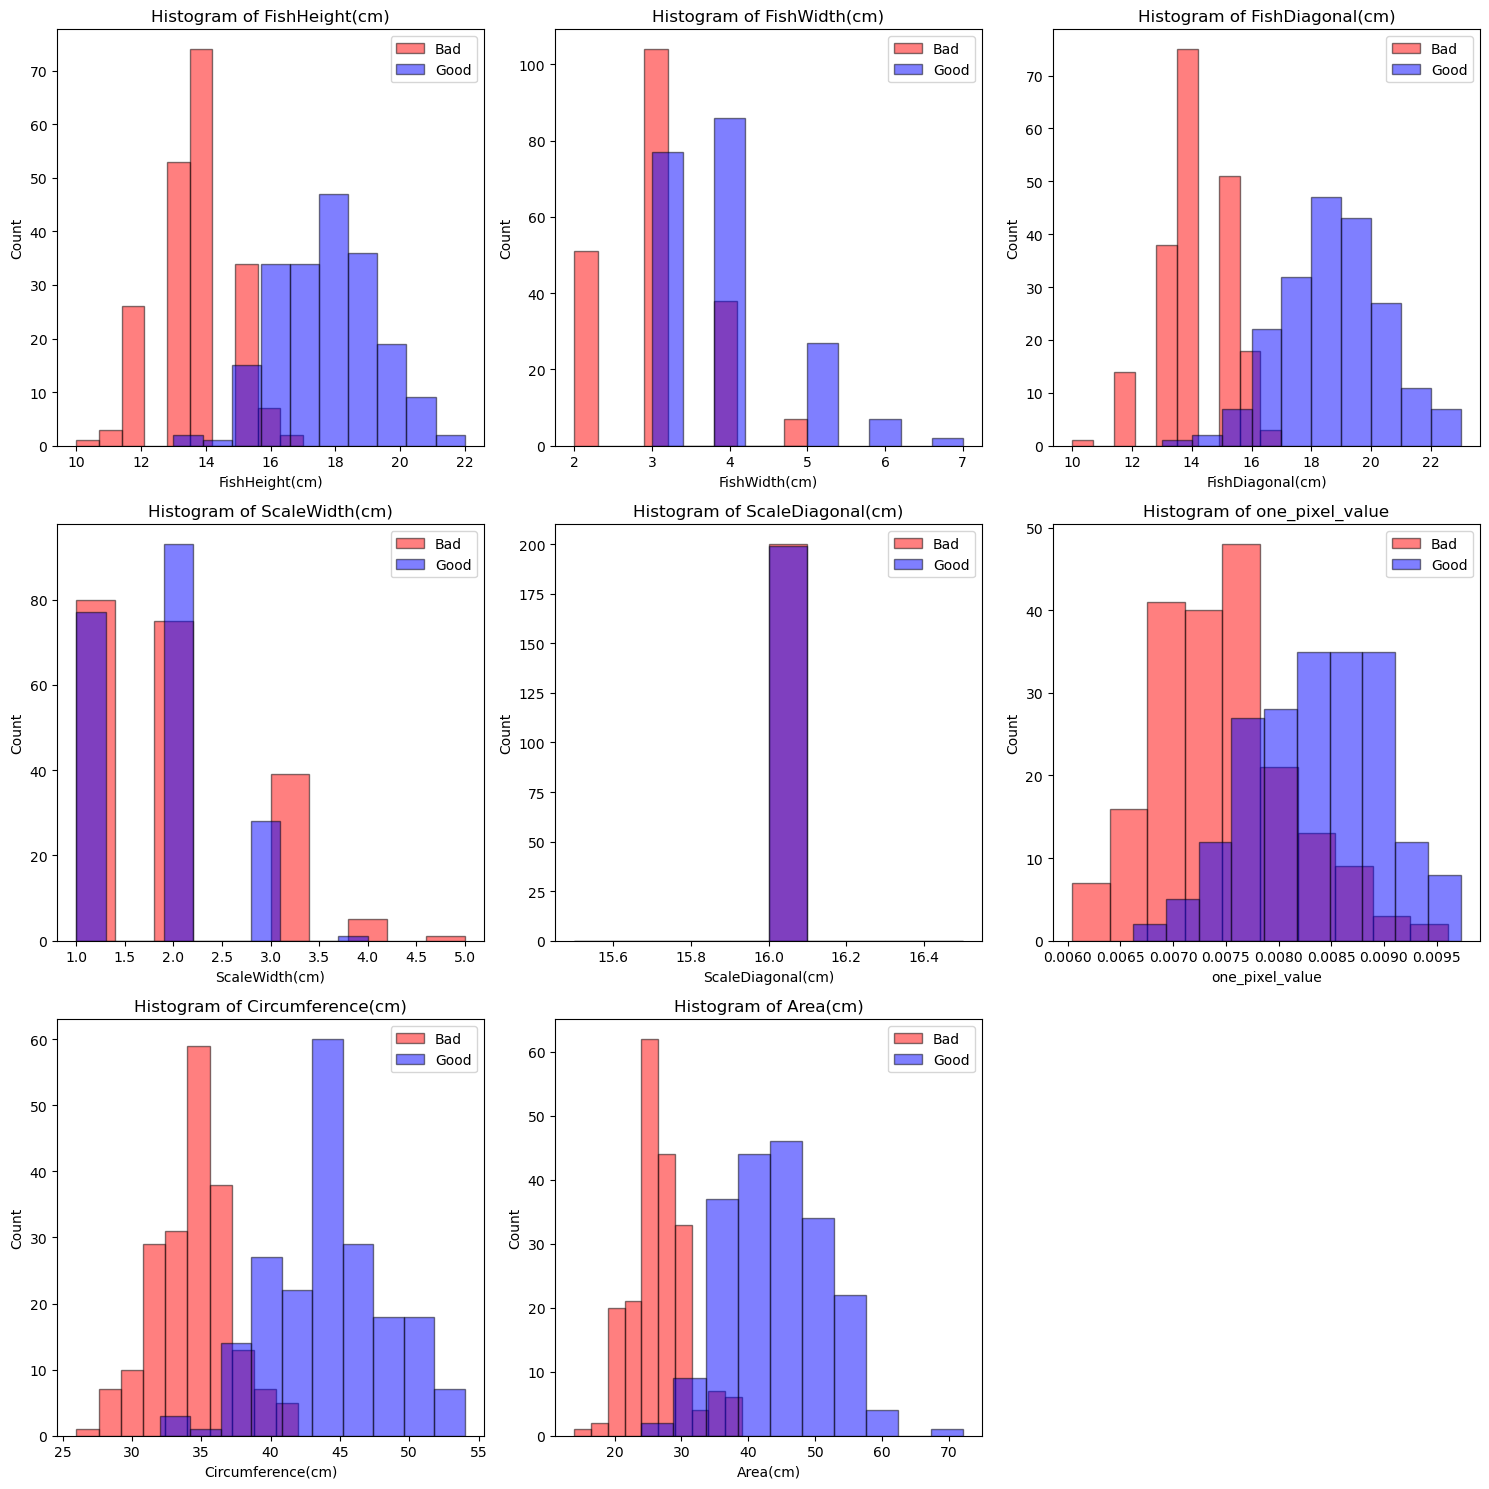

In [79]:
import math

def plot_allhist(colname_list):
    num_plots = len(colname_list)
    num_cols = min(num_plots, 3)  # Assuming a maximum of 3 columns for better visualization
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 15))

    for i, colname in enumerate(colname_list):
        row_index = i // num_cols
        col_index = i % num_cols
        ax = axes[row_index, col_index] if num_plots > 1 else axes
        ax.hist(Bad_df[colname], edgecolor='black', color='red', alpha=0.5, label='Bad')
        ax.hist(Good_df[colname], edgecolor='black', color='blue', alpha=0.5, label='Good')
        ax.set_xlabel(colname)
        ax.set_ylabel('Count')
        ax.set_title(f'Histogram of {colname}')
        ax.legend()

    if num_plots < num_rows * num_cols:
        # Hide empty subplots
        for i in range(num_plots, num_rows * num_cols):
            row_index = i // num_cols
            col_index = i % num_cols
            ax = axes[row_index, col_index] if num_plots > 1 else axes
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_allhist(['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)', 
           'ScaleWidth(cm)', 'ScaleDiagonal(cm)', 'one_pixel_value',
           'Circumference(cm)', 'Area(cm)'])

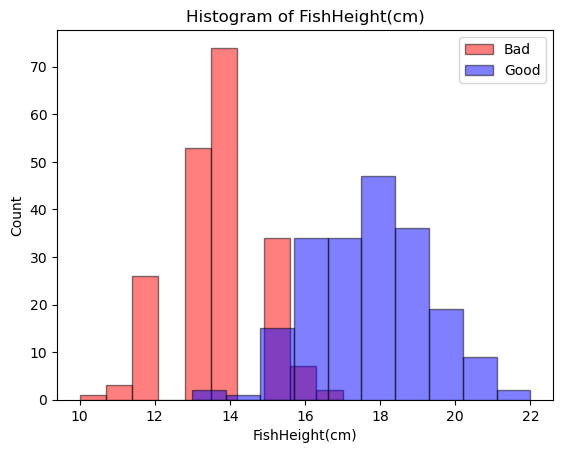

In [80]:
plot_hist('FishHeight(cm)')

In [81]:
Bad_df.columns

Index(['Filename', 'FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'ScaleDiagonal(cm)', 'ScaleWidth(cm)', 'one_pixel_value',
       'Scale Detected', 'Fish Detected', 'Circumference(cm)', 'Area(cm)',
       'Label'],
      dtype='object')

# Test data

In [108]:
Bad_df = k[k['Label']==0]
Good_df = k[k['Label']==1].iloc[:96]

In [109]:
Good_df

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
96,20240222094848026_sardine_good.jpeg,18,4,18,16,3,0.008004,True,True,45.0,42.0,1
97,20240222094855714_sardine_good.jpeg,17,4,18,16,1,0.008625,True,True,43.0,43.0,1
98,20240222094906182_sardine_good.jpeg,19,3,19,16,3,0.008588,True,True,48.0,49.0,1
99,20240222094913384_sardine_good.jpeg,18,3,19,16,2,0.008065,True,True,44.0,49.0,1
100,20240222094922009_sardine_good.jpeg,20,5,21,16,3,0.008845,True,True,53.0,56.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
192,20240224091736138_sardine_good.jpeg,17,3,18,16,2,0.007870,True,True,42.0,45.0,1
193,20240224091743937_sardine_good.jpeg,19,3,20,16,1,0.007882,True,True,49.0,46.0,1
194,20240224091751364_sardine_good.jpeg,18,3,19,16,2,0.007771,True,True,45.0,47.0,1
195,20240224091758654_sardine_good.jpeg,20,5,20,16,2,0.007767,True,True,48.0,49.0,1


In [110]:
Bad_df

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
0,20240326093454488_sardine_bad.jpeg,15,3,16,16,2,0.008151,True,True,39.0,34.0,0
1,20240326093504580_sardine_bad.jpeg,13,3,13,16,1,0.008466,True,True,31.0,25.0,0
2,20240326093517305_sardine_bad.jpeg,14,3,14,16,2,0.009143,True,True,35.0,27.0,0
3,20240326093527435_sardine_bad.jpeg,14,4,14,16,1,0.008351,True,True,34.0,27.0,0
4,20240326093542535_sardine_bad.jpeg,13,3,14,16,1,0.007843,True,True,33.0,27.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
91,20240326101426889_sardine_bad.jpeg,12,3,12,16,1,0.007149,True,True,30.0,25.0,0
92,20240326101456876_sardine_bad.jpeg,10,2,11,16,2,0.005491,True,True,27.0,16.0,0
93,20240326101507317_sardine_bad.jpeg,11,2,11,16,1,0.006990,True,True,27.0,19.0,0
94,20240326101836200_sardine_bad.jpeg,11,3,11,16,3,0.005398,True,True,27.0,18.0,0


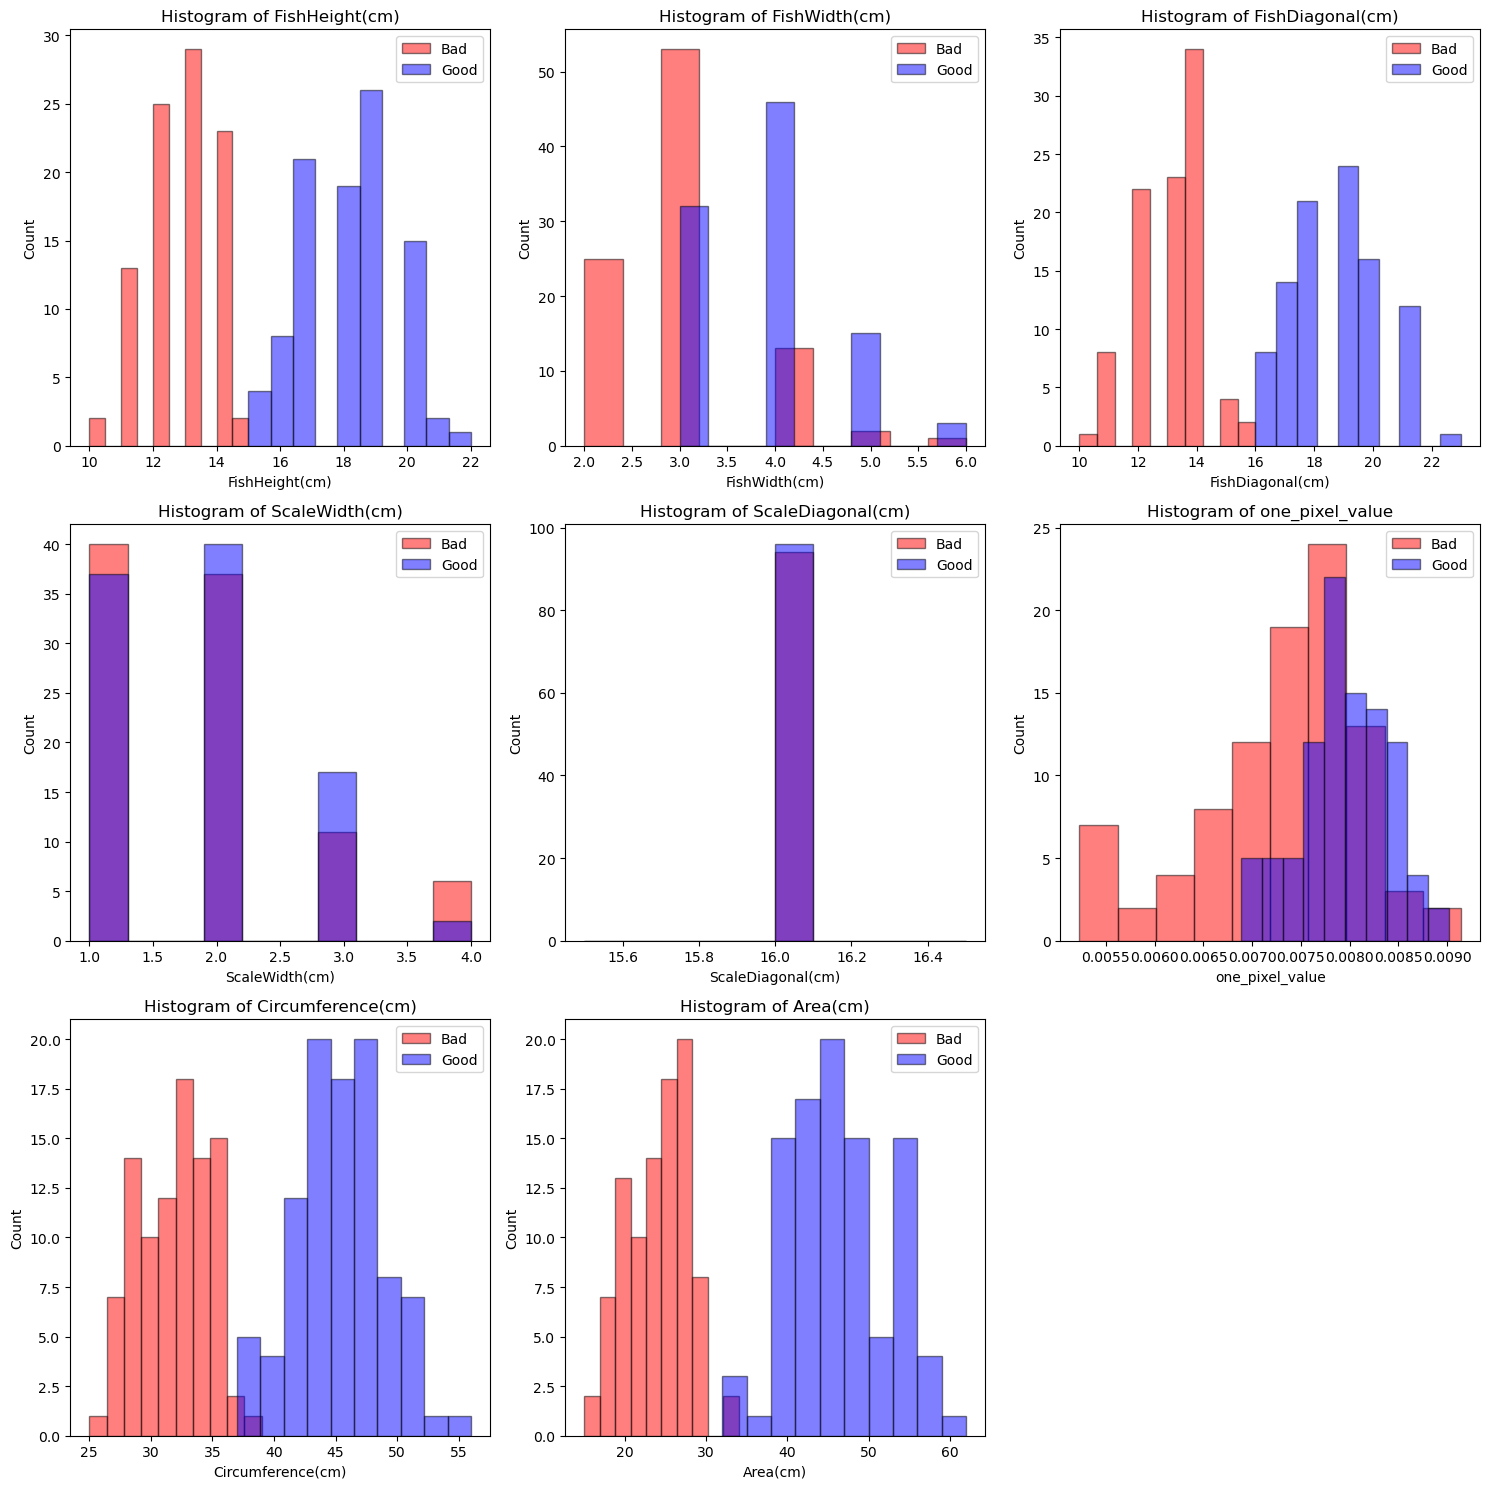

In [111]:
import math

def plot_allhist(colname_list):
    num_plots = len(colname_list)
    num_cols = min(num_plots, 3)  # Assuming a maximum of 3 columns for better visualization
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 15))

    for i, colname in enumerate(colname_list):
        row_index = i // num_cols
        col_index = i % num_cols
        ax = axes[row_index, col_index] if num_plots > 1 else axes
        ax.hist(Bad_df[colname], edgecolor='black', color='red', alpha=0.5, label='Bad')
        ax.hist(Good_df[colname], edgecolor='black', color='blue', alpha=0.5, label='Good')
        ax.set_xlabel(colname)
        ax.set_ylabel('Count')
        ax.set_title(f'Histogram of {colname}')
        ax.legend()

    if num_plots < num_rows * num_cols:
        # Hide empty subplots
        for i in range(num_plots, num_rows * num_cols):
            row_index = i // num_cols
            col_index = i % num_cols
            ax = axes[row_index, col_index] if num_plots > 1 else axes
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_allhist(['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)', 
           'ScaleWidth(cm)', 'ScaleDiagonal(cm)', 'one_pixel_value',
           'Circumference(cm)', 'Area(cm)'])

In [115]:
# m = k.iloc[:1578] # for balanced training data

In [83]:
m = k # for test data

In [84]:
m.shape

(876, 12)

In [85]:
m

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
0,20240326093454488_sardine_bad.jpeg,15,3,16,16,2,0.008151,True,True,39.0,34.0,0
1,20240326093504580_sardine_bad.jpeg,13,3,13,16,1,0.008466,True,True,31.0,25.0,0
2,20240326093517305_sardine_bad.jpeg,14,3,14,16,2,0.009143,True,True,35.0,27.0,0
3,20240326093527435_sardine_bad.jpeg,14,4,14,16,1,0.008351,True,True,34.0,27.0,0
4,20240326093542535_sardine_bad.jpeg,13,3,14,16,1,0.007843,True,True,33.0,27.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
880,IMG_20240227_103027556.jpg,17,4,17,16,1,0.007191,True,True,42.0,38.0,1
881,IMG_20240227_103032795.jpg,15,4,16,16,2,0.006449,True,True,39.0,31.0,1
882,IMG_20240227_103035187.jpg,15,4,16,16,1,0.006826,True,True,39.0,31.0,1
883,IMG_20240227_103038624.jpg,15,3,15,16,1,0.006661,True,True,37.0,28.0,1


In [86]:
m.columns

Index(['Filename', 'FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'ScaleDiagonal(cm)', 'ScaleWidth(cm)', 'one_pixel_value',
       'Scale Detected', 'Fish Detected', 'Circumference(cm)', 'Area(cm)',
       'Label'],
      dtype='object')

In [87]:
# train_df = m[['Height(cm)', 'Circumference(cm)', 
#               'Area(cm)', 'Label']]

train_df = m[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'ScaleDiagonal(cm)', 'ScaleWidth(cm)', 'one_pixel_value',
       'Circumference(cm)', 'Area(cm)', 'Label']]

In [88]:
train_df

,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Circumference(cm),Area(cm),Label
0,15,3,16,16,2,0.008151,39.0,34.0,0
1,13,3,13,16,1,0.008466,31.0,25.0,0
2,14,3,14,16,2,0.009143,35.0,27.0,0
3,14,4,14,16,1,0.008351,34.0,27.0,0
4,13,3,14,16,1,0.007843,33.0,27.0,0
...,...,...,...,...,...,...,...,...,...
880,17,4,17,16,1,0.007191,42.0,38.0,1
881,15,4,16,16,2,0.006449,39.0,31.0,1
882,15,4,16,16,1,0.006826,39.0,31.0,1
883,15,3,15,16,1,0.006661,37.0,28.0,1


In [89]:
# Split the data into features (X) and target variable (y)
# X = train_df[['Height(cm)', 'Circumference(cm)', 'Area(cm)']]  # Features
# X = train_df[['Height(cm)']]  # Features

# V1 89% accuracy logistic regression features with 77% test accuracy on unbalanced data
# X = train_df[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
#        'ScaleDiagonal(cm)', 'ScaleWidth(cm)', 'one_pixel_value',
#        'Circumference(cm)', 'Area(cm)']]  # Features

# V2 88% accuracy logistic regression features with 78% test accuracy on unbalanced data
X = train_df[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'Circumference(cm)', 'Area(cm)']]  # Features

y = train_df['Label']  # Target variable

In [90]:
print("Features (X):")
X.head()

Features (X):


,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),Circumference(cm),Area(cm)
0,15,3,16,39.0,34.0
1,13,3,13,31.0,25.0
2,14,3,14,35.0,27.0
3,14,4,14,34.0,27.0
4,13,3,14,33.0,27.0


In [91]:
print("\nTarget variable (y):")
y.tail()


Target variable (y):


880    1
881    1
882    1
883    1
884    1
Name: Label, dtype: int64

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pickle

In [92]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

In [93]:
y_test.shape, y_train.shape

((80,), (319,))

# Model Training

v3 results

Training Decision Tree...
Accuracy for Decision Tree: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        40
           1       0.92      0.88      0.90        40

    accuracy                           0.90        80
   macro avg       0.90      0.90      0.90        80
weighted avg       0.90      0.90      0.90        80



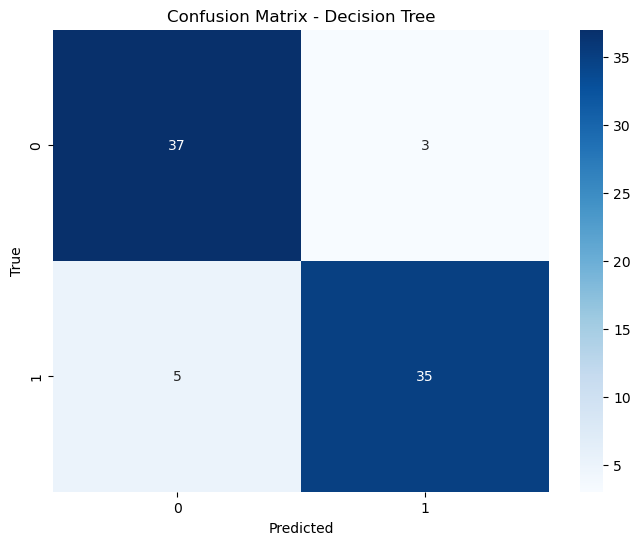

Training Random Forest...
Accuracy for Random Forest: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        40
           1       0.93      0.97      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



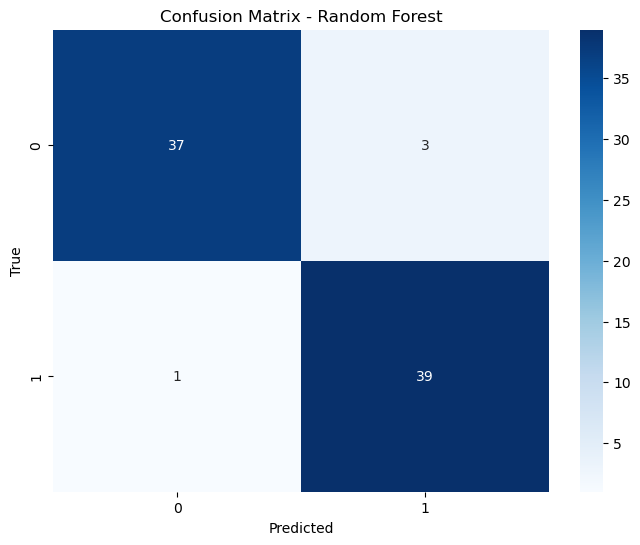

Training K-Nearest Neighbors...
Accuracy for K-Nearest Neighbors: 0.9375

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        40
           1       0.91      0.97      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



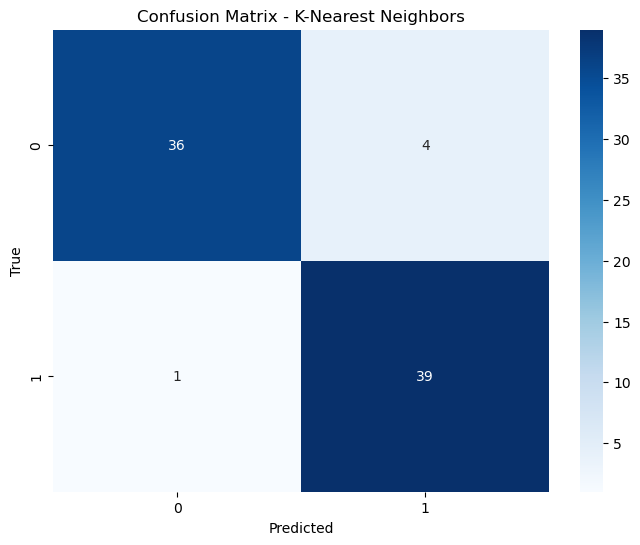

Training Naive Bayes...
Accuracy for Naive Bayes: 0.9625

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        40
           1       0.95      0.97      0.96        40

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



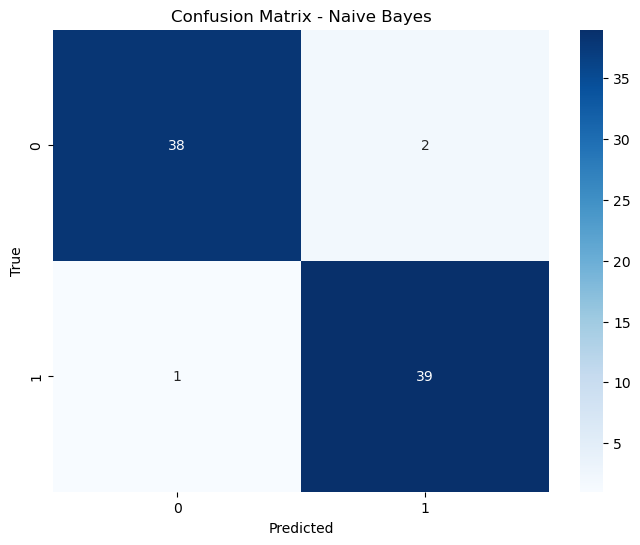

Training XGBClassifier...
Accuracy for XGBClassifier: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        40
           1       0.93      0.97      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



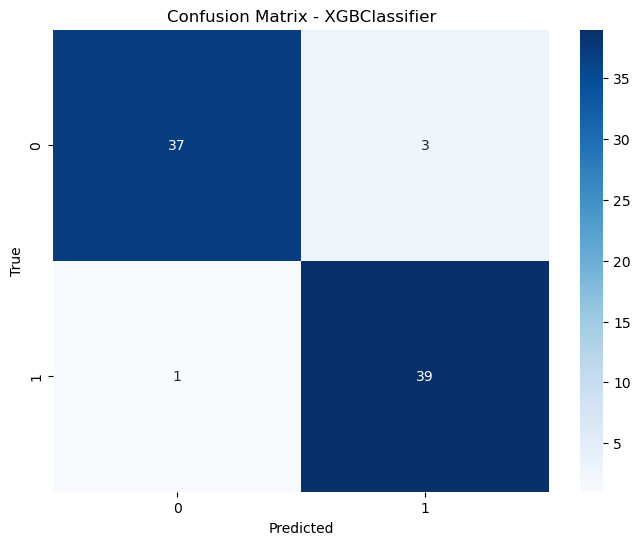

Training Logistic Regression...
Accuracy for Logistic Regression: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        40
           1       0.93      0.97      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



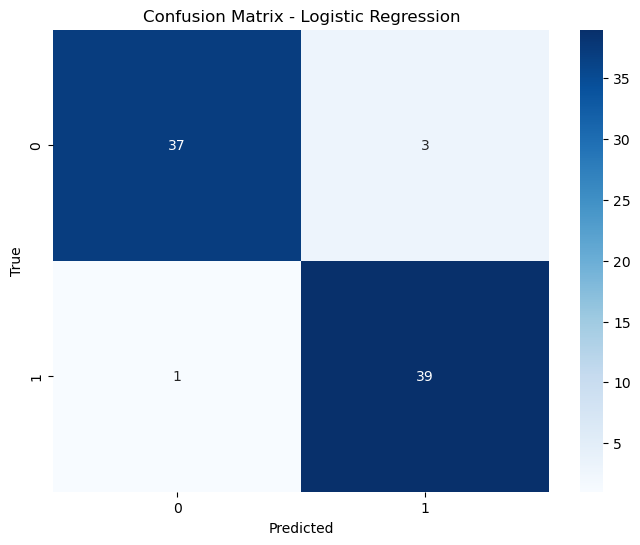

In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Define classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBClassifier": XGBClassifier(),
    "Logistic Regression": LogisticRegression()
}


# Train and evaluate classifiers
for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {name}: {accuracy}\n")

    # Save model
    model_path = f'models/{name}.pkl'
    model = clf
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    
    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Generate classification report
    report = classification_report(y_test, y_pred)

    # Print the classification report
    print("Classification Report:")
    print(report)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    plt.close()

Training Accuracies

Accuracy for Decision Tree.pkl: 0.9937304075235109

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       160
           1       1.00      0.99      0.99       159

    accuracy                           0.99       319
   macro avg       0.99      0.99      0.99       319
weighted avg       0.99      0.99      0.99       319



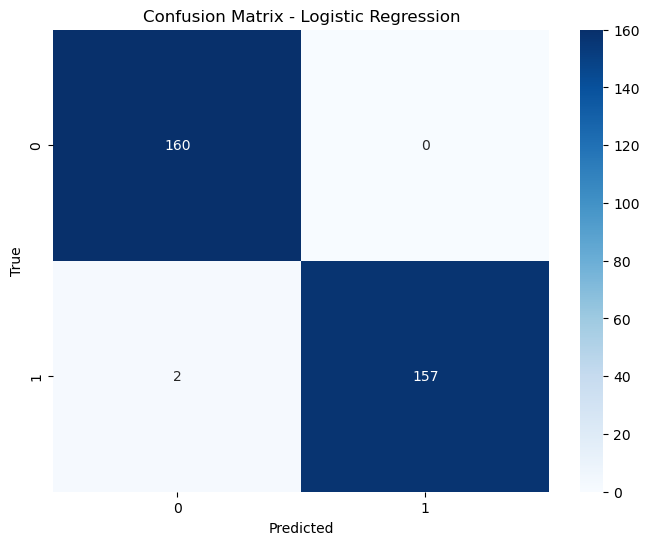

Accuracy for K-Nearest Neighbors.pkl: 0.9341692789968652

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       160
           1       0.93      0.94      0.93       159

    accuracy                           0.93       319
   macro avg       0.93      0.93      0.93       319
weighted avg       0.93      0.93      0.93       319



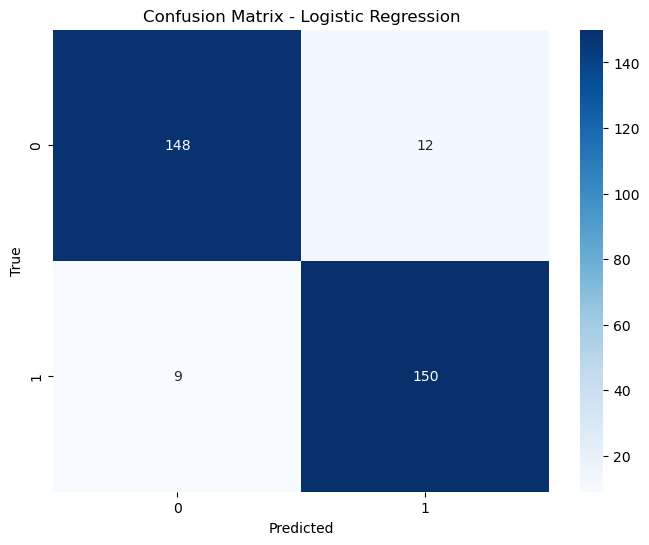

Accuracy for Logistic Regression.pkl: 0.9467084639498433

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       160
           1       0.96      0.94      0.95       159

    accuracy                           0.95       319
   macro avg       0.95      0.95      0.95       319
weighted avg       0.95      0.95      0.95       319



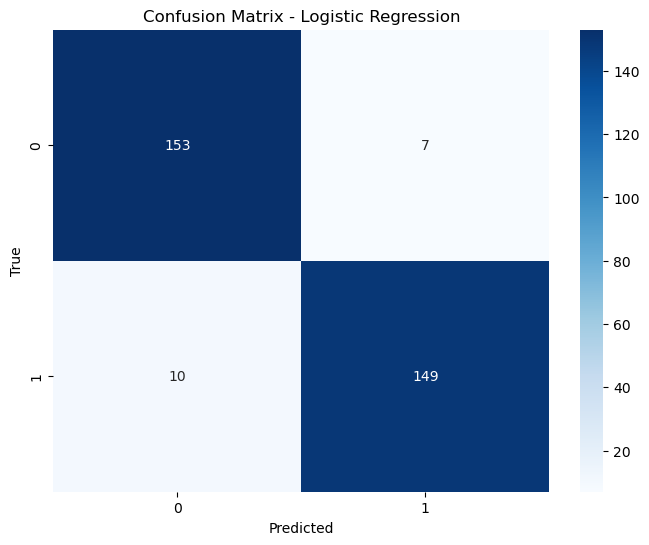

Accuracy for Naive Bayes.pkl: 0.9373040752351097

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       160
           1       0.95      0.92      0.94       159

    accuracy                           0.94       319
   macro avg       0.94      0.94      0.94       319
weighted avg       0.94      0.94      0.94       319



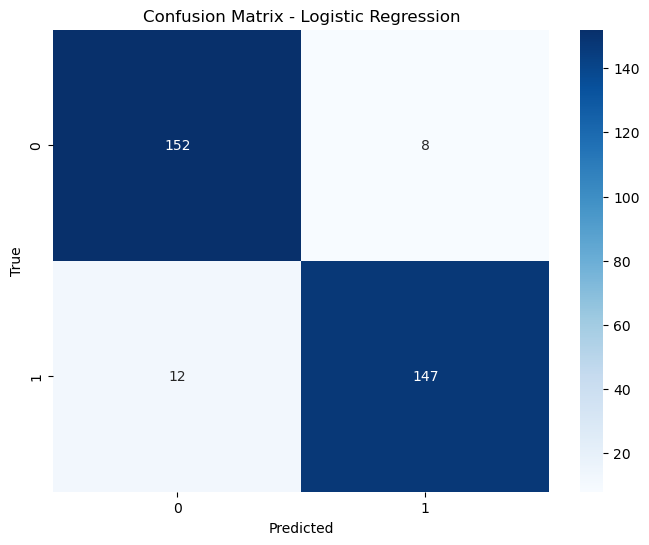

Accuracy for Random Forest.pkl: 0.9937304075235109

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       160
           1       1.00      0.99      0.99       159

    accuracy                           0.99       319
   macro avg       0.99      0.99      0.99       319
weighted avg       0.99      0.99      0.99       319



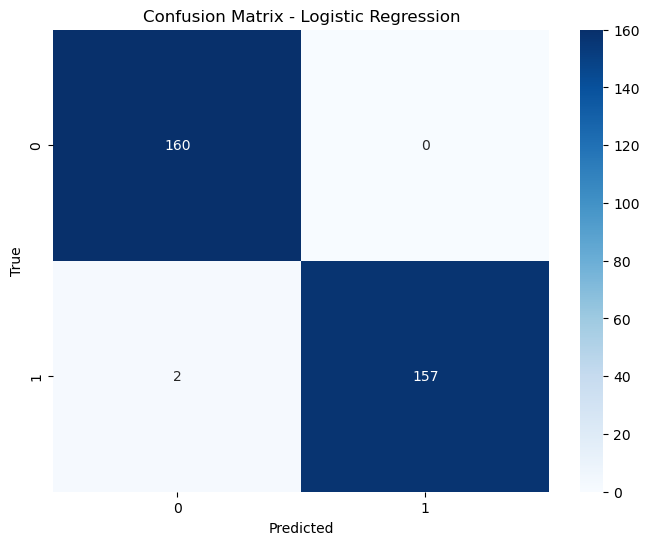

Accuracy for XGBClassifier.pkl: 0.9811912225705329

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       160
           1       0.99      0.97      0.98       159

    accuracy                           0.98       319
   macro avg       0.98      0.98      0.98       319
weighted avg       0.98      0.98      0.98       319



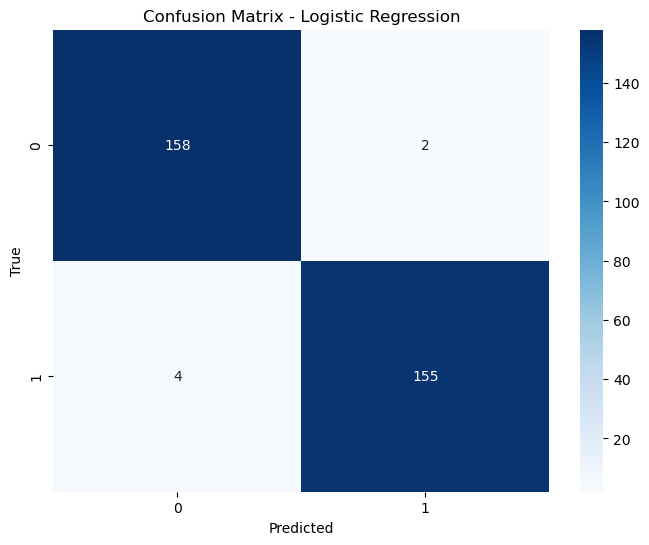

In [95]:
models_folders = r"D:\sardine scale MLmodel\v3\models"

for model in os.listdir(models_folders):
    model_path = os.path.join(models_folders, model)

    # Load model
    with open(model_path, 'rb') as f:
        clf = pickle.load(f)

    # Make predictions
    y_pred = clf.predict(X_train)

    # Calculate accuracy
    accuracy = accuracy_score(y_train, y_pred)
    print(f"Accuracy for {model}: {accuracy}\n")
    
    # Generate confusion matrix
    cm = confusion_matrix(y_train, y_pred)

    # Generate classification report
    report = classification_report(y_train, y_pred)

    # Print the classification report
    print("Classification Report:")
    print(report)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    plt.close()

Testing Accuracies

Accuracy for Decision Tree.pkl: 0.8595890410958904

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.85      0.57        94
           1       0.98      0.86      0.92       782

    accuracy                           0.86       876
   macro avg       0.70      0.86      0.74       876
weighted avg       0.92      0.86      0.88       876



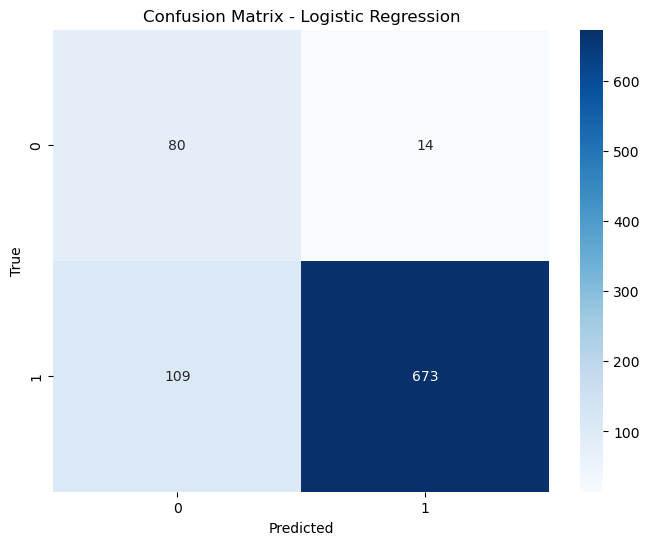

Accuracy for K-Nearest Neighbors.pkl: 0.9394977168949772

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.99      0.78        94
           1       1.00      0.93      0.96       782

    accuracy                           0.94       876
   macro avg       0.82      0.96      0.87       876
weighted avg       0.96      0.94      0.94       876



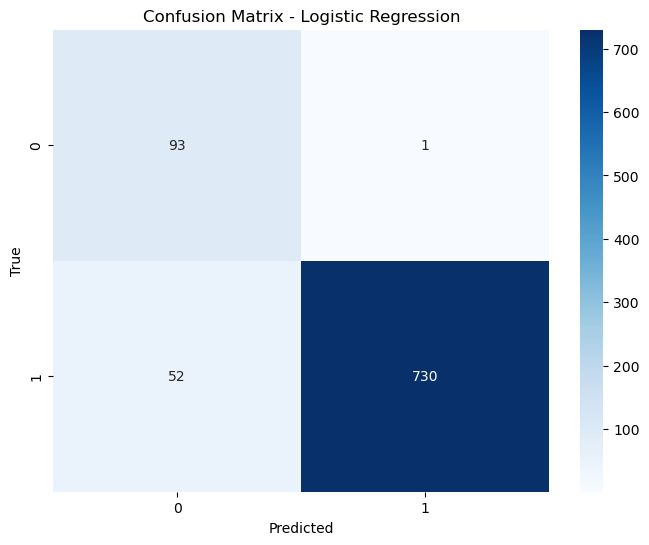

Accuracy for Logistic Regression.pkl: 0.9394977168949772

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.99      0.78        94
           1       1.00      0.93      0.96       782

    accuracy                           0.94       876
   macro avg       0.82      0.96      0.87       876
weighted avg       0.96      0.94      0.94       876



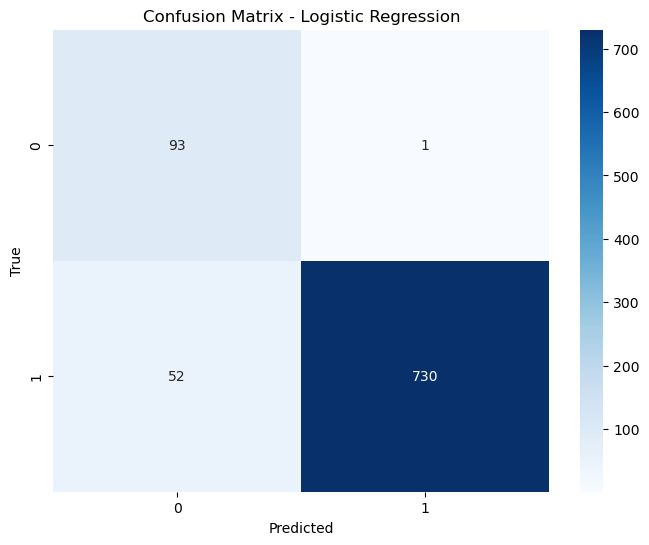

Accuracy for Naive Bayes.pkl: 0.932648401826484

Classification Report:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76        94
           1       1.00      0.92      0.96       782

    accuracy                           0.93       876
   macro avg       0.81      0.96      0.86       876
weighted avg       0.96      0.93      0.94       876



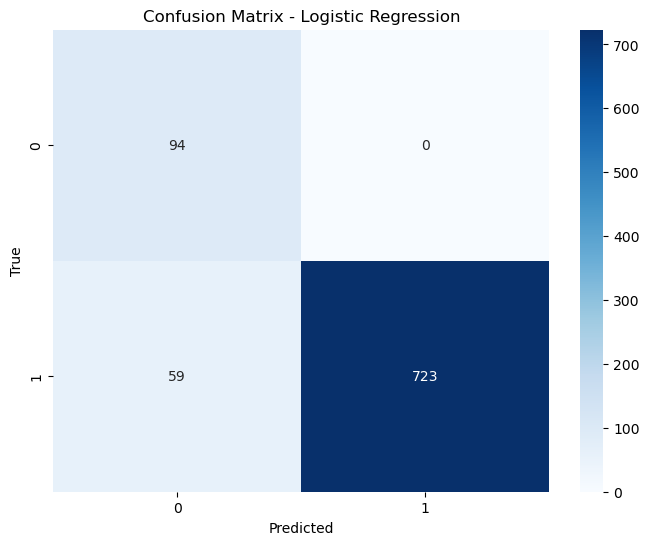

Accuracy for Random Forest.pkl: 0.9315068493150684

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.98      0.75        94
           1       1.00      0.93      0.96       782

    accuracy                           0.93       876
   macro avg       0.81      0.95      0.86       876
weighted avg       0.96      0.93      0.94       876



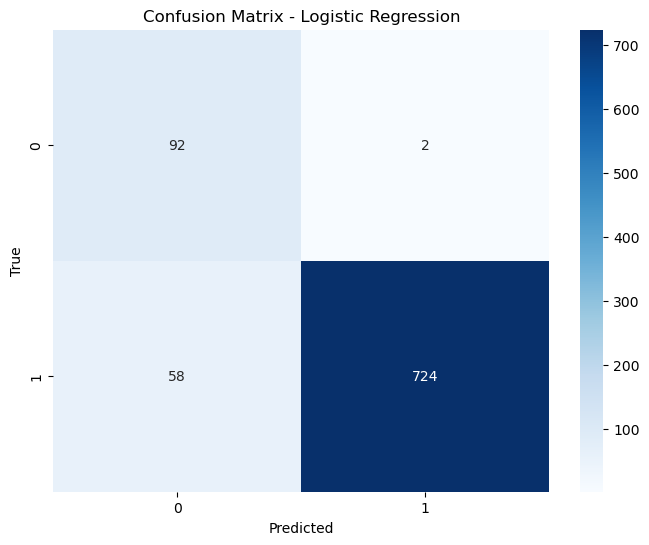

Accuracy for XGBClassifier.pkl: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.98      0.72        94
           1       1.00      0.91      0.95       782

    accuracy                           0.92       876
   macro avg       0.78      0.94      0.83       876
weighted avg       0.95      0.92      0.93       876



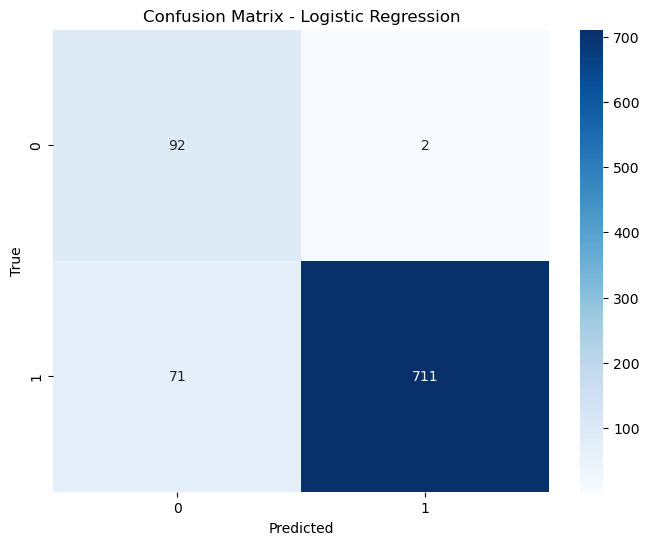

In [125]:
models_folders = r"D:\sardine scale MLmodel\v3\models"

for model in os.listdir(models_folders):
    model_path = os.path.join(models_folders, model)

    # Load model
    with open(model_path, 'rb') as f:
        clf = pickle.load(f)

    # Make predictions
    y_pred = clf.predict(X)

    # Calculate accuracy
    accuracy = accuracy_score(y, y_pred)
    print(f"Accuracy for {model}: {accuracy}\n")
    
    # Generate confusion matrix
    cm = confusion_matrix(y, y_pred)

    # Generate classification report
    report = classification_report(y, y_pred)

    # Print the classification report
    print("Classification Report:")
    print(report)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    plt.close()

Best Model

v3 results

In [58]:
clf = LogisticRegression()
name = "Logistic Regression"
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for {name}: {accuracy}")

Accuracy for Logistic Regression: 0.8765822784810127


Save Best Model

In [47]:
model_path = 'logistic_regression3.pkl'

In [60]:
model = clf
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

Load the ML model

In [93]:
model_path = r"D:\sardine scale MLmodel\v3\models\Logistic Regression.pkl"

In [94]:
with open(model_path, 'rb') as f:
    model = pickle.load(f)

Test with a folder data

v3 results

In [92]:
X_test = X
y_test = y

# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for model: {accuracy}\n")

# Generate classification report
report = classification_report(y_test, y_pred)

# Print the classification report
print("Classification Report:")
print(report)

Accuracy for model: 0.7781155015197568

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.70      0.82       240
           1       0.55      0.98      0.70        89

    accuracy                           0.78       329
   macro avg       0.77      0.84      0.76       329
weighted avg       0.87      0.78      0.79       329



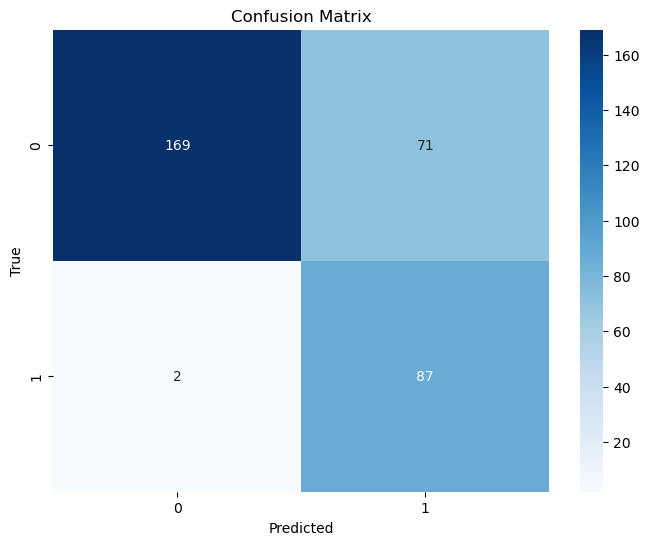

In [93]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix')
plt.show()
plt.close()

# Test an image

In [160]:
test = pd.read_csv(r"D:\sardine scale MLmodel\test_img_data.csv")
test

,Filename,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Scale,Fish,Circumference,Area
0,20240224091224451_sardine_good.jpeg,16,3,17,16,1,0.008197,True,True,41,34


In [161]:
def pred_single_img(test, model):
    predictions = []
    for index, row in test.iterrows():
        if row['Scale']==False:
            print(f'Scale not detected @ {index}')
            break
        if row['Fish']==False:
            print(f'Fish not detected @ {index}')
            break
        Height = row['FishHeight']
        Width = row['FishWidth']
        diagonal = row['FishDiagonal']
        Circumference = row['Circumference']
        Area = row['Area']
        X_test = [[Height, Width, diagonal, Circumference, Area]]
        pred = model.predict(X_test)
        # Get probability estimates for the predicted labels
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)
            print(f"Probability :", y_proba)
        predictions.append(pred)
    return predictions

In [162]:
predictions = pred_single_img(test, model)

Probability : [[0.59628599 0.40371401]]


c:\Users\sowmy\anaconda3\envs\opencv_env\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\sowmy\anaconda3\envs\opencv_env\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [163]:
predictions

[array([0], dtype=int64)]

In [158]:
for i in predictions:
    print(i[0])

0


# Misclassified data

v3 results

In [95]:
# Evaluate the model
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy for model: {accuracy}\n")

# Generate classification report
report = classification_report(y, y_pred)

# Print the classification report
print("Classification Report:")
print(report)

Accuracy for model: 0.9394977168949772

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.99      0.78        94
           1       1.00      0.93      0.96       782

    accuracy                           0.94       876
   macro avg       0.82      0.96      0.87       876
weighted avg       0.96      0.94      0.94       876



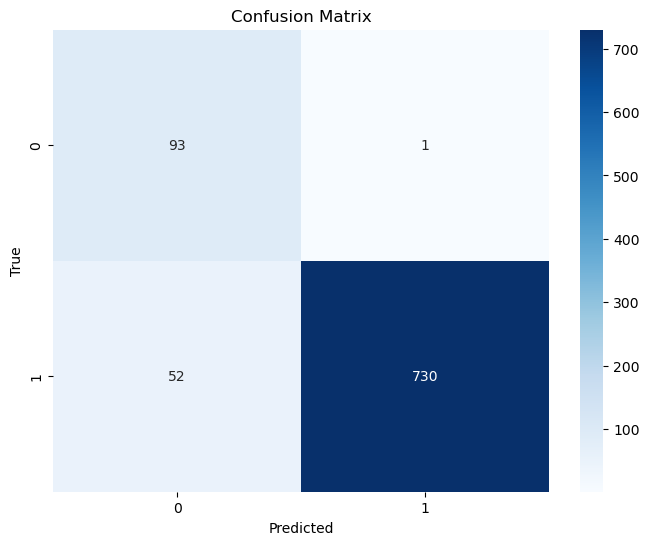

In [96]:
# Generate confusion matrix
cm = confusion_matrix(y, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix')
plt.show()
plt.close()

In [97]:
m.shape

(876, 12)

In [98]:
# Create a DataFrame containing the test data and corresponding true labels and predictions
results_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})

# Get the indices of misclassified data points
accurate_indices = results_df[results_df['Actual'] == results_df['Predicted']].index

# Filter the original DataFrame using the misclassified indices
accurate_data_df = m.loc[accurate_indices]
accurate_data_df

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
0,20240326093454488_sardine_bad.jpeg,15,3,16,16,2,0.008151,True,True,39.0,34.0,0
1,20240326093504580_sardine_bad.jpeg,13,3,13,16,1,0.008466,True,True,31.0,25.0,0
2,20240326093517305_sardine_bad.jpeg,14,3,14,16,2,0.009143,True,True,35.0,27.0,0
3,20240326093527435_sardine_bad.jpeg,14,4,14,16,1,0.008351,True,True,34.0,27.0,0
4,20240326093542535_sardine_bad.jpeg,13,3,14,16,1,0.007843,True,True,33.0,27.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
872,IMG_20240227_101123947.jpg,16,3,17,16,1,0.007703,True,True,41.0,37.0,1
874,IMG_20240227_101132423.jpg,15,3,16,16,2,0.007217,True,True,38.0,35.0,1
879,IMG_20240227_103023117.jpg,15,3,15,16,1,0.007937,True,True,38.0,35.0,1
880,IMG_20240227_103027556.jpg,17,4,17,16,1,0.007191,True,True,42.0,38.0,1


In [101]:
good3 = accurate_data_df[accurate_data_df['Label']==1]
bad3 = accurate_data_df[accurate_data_df['Label']==0]

In [132]:
X3 = good3[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'Circumference(cm)', 'Area(cm)']]  # Features
y3 = good3['Label']  # Target variable

In [133]:
y3.shape

(730,)

In [134]:
probabilities = model.predict_proba(X3)

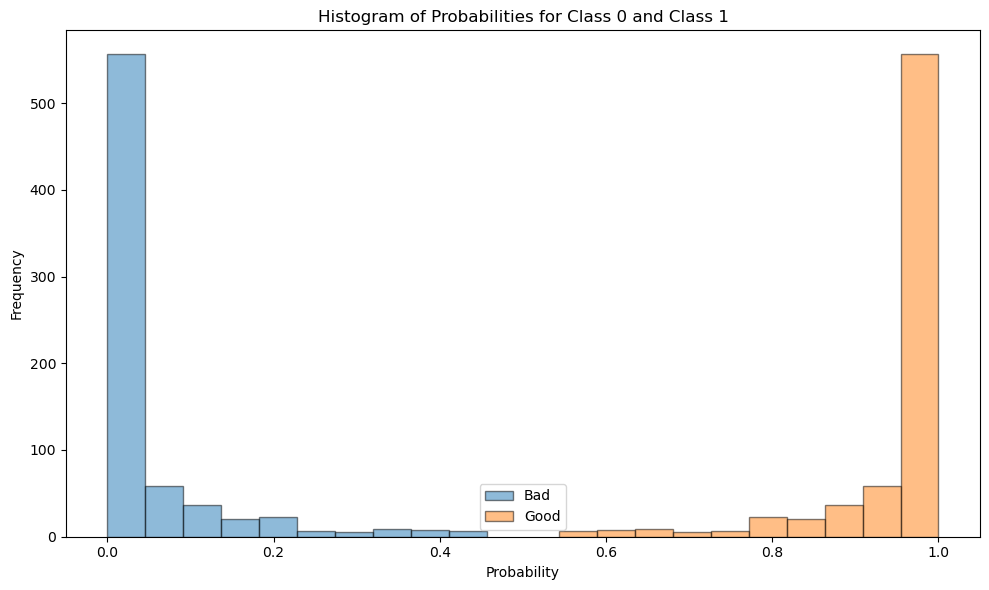

In [135]:
# Extract probabilities for Class 0 and Class 1
prob_class_0 = probabilities[:, 0]
prob_class_1 = probabilities[:, 1]

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(prob_class_0, edgecolor='black', alpha=0.5, label='Bad')
plt.hist(prob_class_1, edgecolor='black', alpha=0.5, label='Good')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Probabilities for Class 0 and Class 1')
plt.tight_layout()
plt.legend()
plt.show()

In [136]:
[i>0.8 for i in prob_class_1].count(True)

681

In [137]:
730-681

49

In [109]:
prob_class_1[1]

0.99300346223325

In [138]:
X3 = bad3[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'Circumference(cm)', 'Area(cm)']]  # Features
y3 = bad3['Label']  # Target variable

In [139]:
y3.shape

(93,)

In [140]:
probabilities = model.predict_proba(X3)

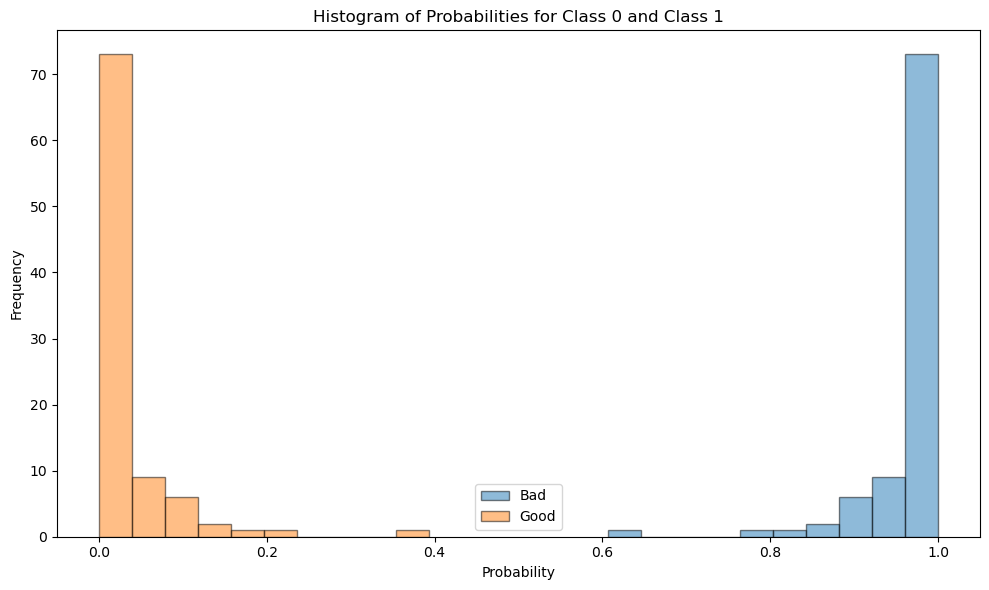

In [141]:
# Extract probabilities for Class 0 and Class 1
prob_class_0 = probabilities[:, 0]
prob_class_1 = probabilities[:, 1]

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(prob_class_0, edgecolor='black', alpha=0.5, label='Bad')
plt.hist(prob_class_1, edgecolor='black', alpha=0.5, label='Good')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Probabilities for Class 0 and Class 1')
plt.tight_layout()
plt.legend()
plt.show()

In [142]:
[i>0.8 for i in prob_class_0].count(True)

91

In [143]:
93-91

2

In [44]:
# Create a DataFrame containing the test data and corresponding true labels and predictions
results_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})

# Get the indices of misclassified data points
misclassified_indices = results_df[results_df['Actual'] != results_df['Predicted']].index

# Filter the original DataFrame using the misclassified indices
misclassified_data_df = m.loc[misclassified_indices]
misclassified_data_df

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
77,20240326100634650_sardine_bad.jpeg,14,4,14,16,4,0.007733,True,True,35.0,33.0,0
165,20240224091224451_sardine_good.jpeg,16,3,17,16,1,0.008197,True,True,41.0,34.0,1
166,20240224091231401_sardine_good.jpeg,15,3,16,16,1,0.007917,True,True,37.0,32.0,1
293,20240302102742241_sardine_good.jpeg,15,3,15,16,1,0.008089,True,True,37.0,33.0,1
336,20240312132433689_sardine_good.jpeg,15,3,15,16,2,0.008593,True,True,37.0,33.0,1
348,20240312132613041_sardine_good.jpeg,15,3,15,16,3,0.008020,True,True,35.0,32.0,1
418,20240313111944574_sardine_good.jpeg,15,3,15,16,1,0.008570,True,True,36.0,32.0,1
419,20240313111953842_sardine_good.jpeg,15,4,16,16,1,0.009217,True,True,39.0,32.0,1
452,20240313112541971_sardine_good.jpeg,14,3,15,16,2,0.008036,True,True,35.0,31.0,1
453,20240313112550131_sardine_good.jpeg,15,3,15,16,3,0.008247,True,True,36.0,32.0,1


In [45]:
misclassified_data_df['Label'].value_counts()

1    52
0     1
Name: Label, dtype: int64

Analyze misclassifications

In [135]:
# Train data
Bad_df = misclassified_data_df[misclassified_data_df['Label']==0]
# Good_df = misclassified_data_df[misclassified_data_df['Label']==1].iloc[:95]
Good_df = misclassified_data_df[misclassified_data_df['Label']==1]

In [136]:
def plot_hist(colname):
    # Plot histogram with black edges
    plt.figure()
    plt.hist(Bad_df[colname], edgecolor='black', color='red', alpha=0.5, label='Bad')
    plt.hist(Good_df[colname], edgecolor='black', color='blue', alpha=0.5, label='Good')
    plt.xlabel(colname)
    plt.ylabel('Count')
    plt.title(f'Histogram of {colname}')
    plt.legend()
    plt.show()

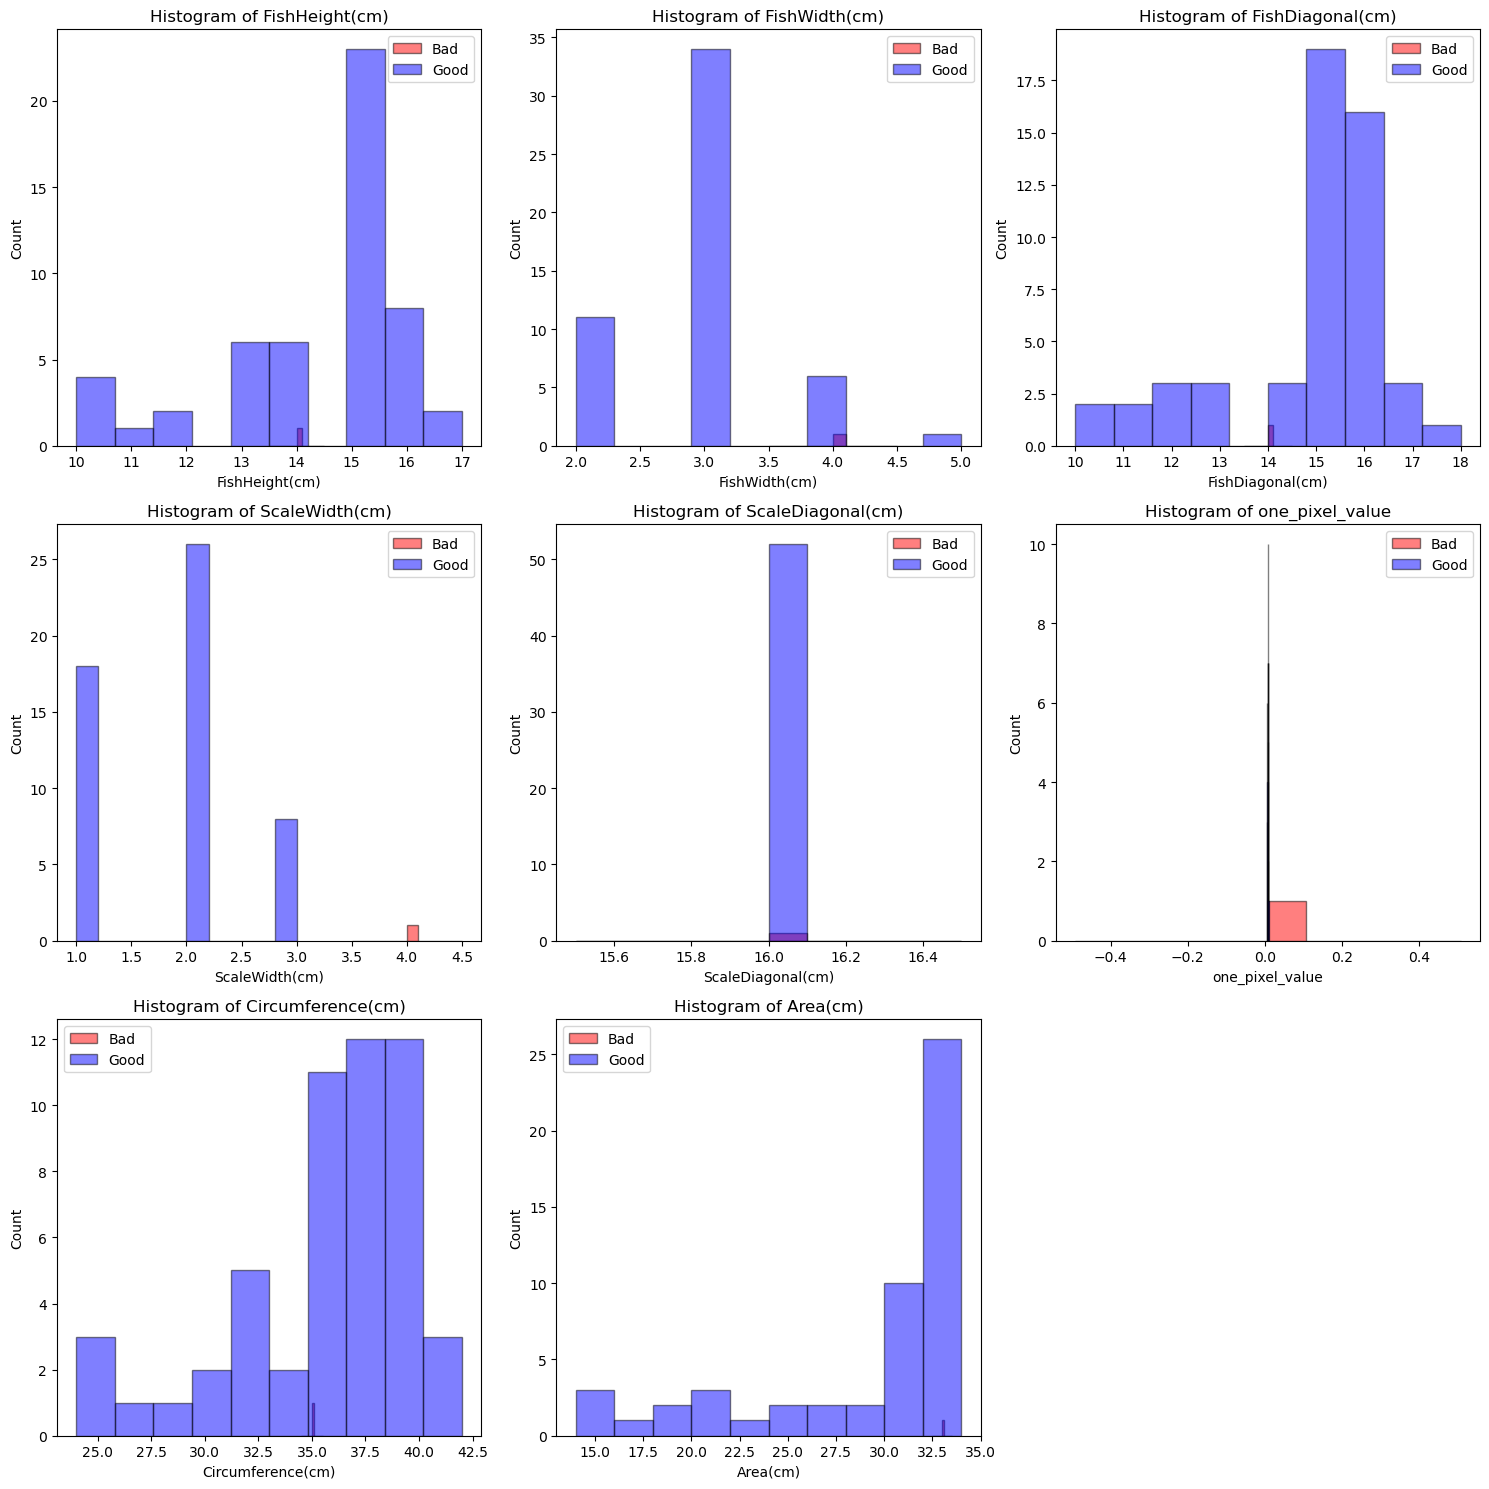

In [137]:
import math

def plot_allhist(colname_list):
    num_plots = len(colname_list)
    num_cols = min(num_plots, 3)  # Assuming a maximum of 3 columns for better visualization
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 15))

    for i, colname in enumerate(colname_list):
        row_index = i // num_cols
        col_index = i % num_cols
        ax = axes[row_index, col_index] if num_plots > 1 else axes
        ax.hist(Bad_df[colname], edgecolor='black', color='red', alpha=0.5, label='Bad')
        ax.hist(Good_df[colname], edgecolor='black', color='blue', alpha=0.5, label='Good')
        ax.set_xlabel(colname)
        ax.set_ylabel('Count')
        ax.set_title(f'Histogram of {colname}')
        ax.legend()

    if num_plots < num_rows * num_cols:
        # Hide empty subplots
        for i in range(num_plots, num_rows * num_cols):
            row_index = i // num_cols
            col_index = i % num_cols
            ax = axes[row_index, col_index] if num_plots > 1 else axes
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_allhist(['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)', 
           'ScaleWidth(cm)', 'ScaleDiagonal(cm)', 'one_pixel_value',
           'Circumference(cm)', 'Area(cm)'])

In [115]:
X = misclassified_data_df[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'Circumference(cm)', 'Area(cm)']]  # Features
y = misclassified_data_df['Label']  # Target variable

In [116]:
y.shape

(53,)

In [144]:
probabilities = model.predict_proba(X)

In [148]:
probabilities.shape

(53, 2)

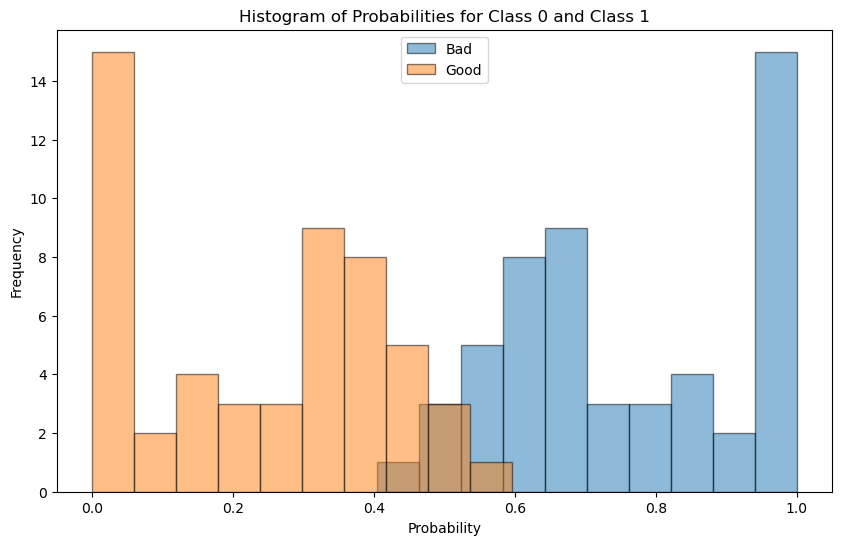

In [145]:
# Extract probabilities for Class 0 and Class 1
prob_class_0 = probabilities[:, 0]
prob_class_1 = probabilities[:, 1]

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(prob_class_0, edgecolor='black', alpha=0.5, label='Bad')
plt.hist(prob_class_1, edgecolor='black', alpha=0.5, label='Good')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Probabilities for Class 0 and Class 1')
plt.legend()
plt.show()

In [130]:
[i>0.8 for i in prob_class_0].count(True)

23

In [152]:
data_array = probabilities
filtered_rows = data_array[(data_array[:, 0] >= 0.8)]
filtered_rows

array([[8.03830849e-01, 1.96169151e-01],
       [8.34990182e-01, 1.65009818e-01],
       [8.25737753e-01, 1.74262247e-01],
       [9.19494461e-01, 8.05055394e-02],
       [8.73844427e-01, 1.26155573e-01],
       [8.00630030e-01, 1.99369970e-01],
       [8.41409732e-01, 1.58590268e-01],
       [9.28125171e-01, 7.18748295e-02],
       [9.99792728e-01, 2.07272302e-04],
       [9.66275662e-01, 3.37243383e-02],
       [9.99900461e-01, 9.95390283e-05],
       [9.99965355e-01, 3.46453618e-05],
       [9.99826514e-01, 1.73486005e-04],
       [9.99038531e-01, 9.61468746e-04],
       [9.97390187e-01, 2.60981290e-03],
       [9.77945631e-01, 2.20543693e-02],
       [9.99661737e-01, 3.38263222e-04],
       [9.99940380e-01, 5.96197647e-05],
       [9.87754808e-01, 1.22451917e-02],
       [9.99038531e-01, 9.61468746e-04],
       [9.97958108e-01, 2.04189213e-03],
       [9.91114966e-01, 8.88503446e-03],
       [9.46221805e-01, 5.37781948e-02]])

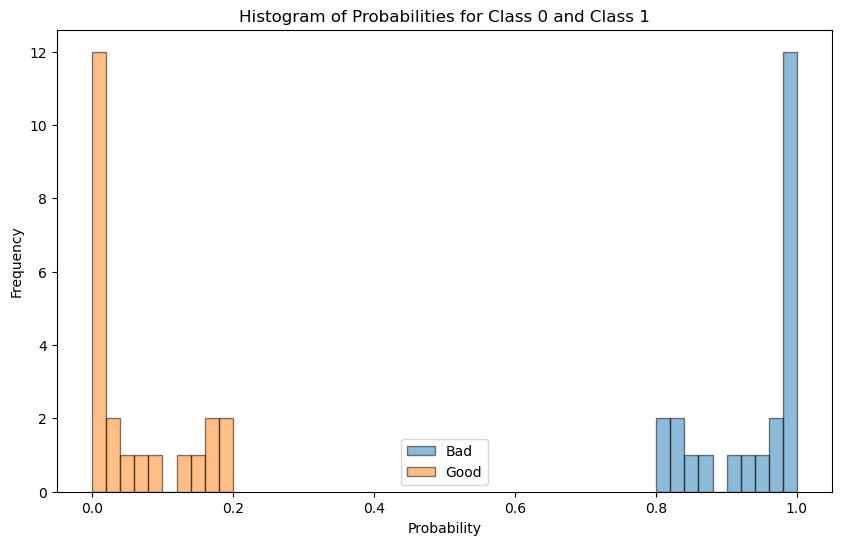

In [154]:
# Extract probabilities for Class 0 and Class 1
prob_class_0 = filtered_rows[:, 0]
prob_class_1 = filtered_rows[:, 1]

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(prob_class_0, edgecolor='black', alpha=0.5, label='Bad')
plt.hist(prob_class_1, edgecolor='black', alpha=0.5, label='Good')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Probabilities for Class 0 and Class 1')
plt.legend()
plt.show()

In [146]:
53-23

30

In [173]:
feedback_df = pd.read_csv(r"C:\Users\sowmy\Downloads\QzenseLabs\testing_dataset2.csv")
feedback_df['Filename'] = feedback_df['image_url'].apply(lambda x: os.path.basename(x))
feedback_df['Date'] = feedback_df['Filename'].apply(lambda x: os.path.splitext(x)[0].split('_')[0])
feedback_df['Date'] = feedback_df['Date'].apply(lambda x: f'{x[0:4]}-{x[4:6]}-{x[6:8]}')
feedback_df.drop(['image_url', 'Unnamed: 0'], axis=1, inplace=True)

In [174]:
feedback_df

,id,type,labels,description,Filename,Date
0,51761,white prawns,bad,Softness,20240306105949897_white prawns_bad.jpeg,2024-03-06
1,24398,white prawns,bad,Red Head in Prawns,20230923093438588_white prawns_bad.jpeg,2023-09-23
2,51762,white prawns,bad,Softness,20240306105957000_white prawns_bad.jpeg,2024-03-06
3,24410,white prawns,bad,Red Head in Prawns,20230923094928373_white prawns_bad.jpeg,2023-09-23
4,24411,white prawns,bad,Red Head in Prawns,20230923094938856_white prawns_bad.jpeg,2023-09-23
...,...,...,...,...,...,...
16083,60837,white prawns,bad,Red Head in Prawns,20240414100018804_white prawns_bad.jpeg,2024-04-14
16084,60838,white prawns,bad,Cuts and Damage,20240414100053942_white prawns_bad.jpeg,2024-04-14
16085,60839,white prawns,bad,Cuts and Damage,20240414100106748_white prawns_bad.jpeg,2024-04-14
16086,60840,white prawns,bad,Cuts and Damage,20240414100119057_white prawns_bad.jpeg,2024-04-14


In [175]:
feedback_df['labels'].value_counts()

bad     16067
good       21
Name: labels, dtype: int64

In [176]:
filtered_df = feedback_df[feedback_df['description'].str.contains('Size')]
filtered_df = filtered_df[filtered_df['labels']=='bad']
filtered_df = filtered_df[filtered_df['type']=='sardine']

In [177]:
filtered_df.shape

(431, 6)

In [178]:
filtered_df['Date'].unique() # 2024-03-27, 2024-03-28, 2024-03-30, 2024-04-05 have different scales. 
                             # So we can't use that data for scale detection

array(['2023-12-01', '2023-12-05', '2023-12-17', '2023-12-23',
       '2024-01-30', '2024-01-31', '2024-02-03', '2024-02-20',
       '2024-02-22', '2024-02-28', '2024-02-29', '2024-03-12',
       '2024-03-13', '2024-03-19', '2024-03-20', '2024-03-23',
       '2024-03-26', '2024-03-27', '2024-03-28', '2024-03-30',
       '2024-04-05'], dtype=object)

In [179]:
filtered_df['Date'].nunique()

21

In [51]:
src_dir = r"C:\Users\sowmy\Downloads\QzenseLabs\qZense Dataset\S3 Daily Data"
des_dir = r"D:\sardine scale MLmodel\v3\test\Bad"

import shutil
from tqdm import tqdm

for date in tqdm(filtered_df['Date'].unique()):
    folder = os.path.join(src_dir, date, 'Sardine', 'Bad')
    if '2024-01-30'<=date and date<='2024-03-26': 
        df = filtered_df[filtered_df['Date']==date]['Filename']
        if len(os.listdir(folder))==1: 
            folder = os.path.join(src_dir, date, 'Sardine', 'Bad', 'Single')
        for file in os.listdir(folder):
            filepath = os.path.join(folder, file)
            if os.path.isdir(filepath): 
                if file=='Single':
                    for f in os.listdir(filepath):
                        if f in df.values:
                            shutil.copy(os.path.join(filepath, f), des_dir)
            else:
                if file in df.values:
                    shutil.copy(filepath, des_dir)

100%|██████████| 21/21 [00:00<00:00, 45.73it/s]


In [22]:
filtered_df = feedback_df[feedback_df['Filename'].isin(misclassified_data_df['Filename'])]

NameError: name 'misclassified_data_df' is not defined

In [108]:
misclassified_data_df.shape

(205, 12)

In [103]:
filtered_df['description'].value_counts()

Softness                     56
Cuts and Damage              11
Softness, Cuts and Damage     7
Cuts and Damage, Softness     3
Size                          2
Name: description, dtype: int64

In [104]:
filtered_df.shape

(79, 6)

# Train Data

In [47]:
m=n

In [48]:
filtered_df = feedback_df[feedback_df['Filename'].isin(m['Filename'])]

In [49]:
filtered_df['labels'].value_counts()

bad    632
Name: labels, dtype: int64

In [50]:
filtered_df

,id,type,labels,description,Filename,Date
14908,58993,sardine,bad,"Cuts and Damage, Softness",20240405093420275_sardine_bad.jpeg,2024-04-05
14909,58994,sardine,bad,Softness,20240405093435386_sardine_bad.jpeg,2024-04-05
14910,58995,sardine,bad,"Softness, Cuts and Damage",20240405093450624_sardine_bad.jpeg,2024-04-05
14911,58996,sardine,bad,Softness,20240405093507767_sardine_bad.jpeg,2024-04-05
14912,58997,sardine,bad,Softness,20240405093519297_sardine_bad.jpeg,2024-04-05
...,...,...,...,...,...,...
15538,59642,sardine,bad,Softness,20240405105822727_sardine_bad.jpeg,2024-04-05
15539,59643,sardine,bad,Softness,20240405105826174_sardine_bad.jpeg,2024-04-05
15540,59644,sardine,bad,Softness,20240405105839511_sardine_bad.jpeg,2024-04-05
15541,59645,sardine,bad,Softness,20240405105851873_sardine_bad.jpeg,2024-04-05


In [51]:
filtered_df['description'].value_counts()

Softness                           542
Softness, Cuts and Damage           63
Cuts and Damage, Softness           20
Size, Softness                       3
Softness, Size                       1
Size                                 1
Size, Softness, Cuts and Damage      1
Softness, Cuts and Damage, Size      1
Name: description, dtype: int64

In [52]:
filtered_df.shape

(632, 6)

In [53]:
filtered_df = (filtered_df[filtered_df['description'].str.contains('Size')])

In [54]:
filtered_df['labels'].value_counts()

bad    7
Name: labels, dtype: int64

In [55]:
filtered_df['description'].value_counts()

Size, Softness                     3
Softness, Size                     1
Size                               1
Size, Softness, Cuts and Damage    1
Softness, Cuts and Damage, Size    1
Name: description, dtype: int64

In [31]:
filtered_df.shape

(3, 6)

In [32]:
filtered_df

,id,type,labels,description,Filename,Date
14988,59073,sardine,bad,"Softness, Size",20240405095138191_sardine_bad.jpeg,2024-04-05
15262,59352,sardine,bad,"Size, Softness",20240405102434851_sardine_bad.jpeg,2024-04-05
15347,59451,sardine,bad,"Softness, Cuts and Damage, Size",20240405103828114_sardine_bad.jpeg,2024-04-05


In [33]:
train_df.shape

NameError: name 'train_df' is not defined

In [34]:
new_df = m[m['Filename'].isin(filtered_df['Filename'])]

In [35]:
new_df

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
77,20240405095138191_sardine_bad.jpeg,12,3,13,16,2,0.005135,True,True,31.0,21.0,0
351,20240405102434851_sardine_bad.jpeg,12,2,12,16,1,0.005766,True,True,31.0,24.0,0
436,20240405103828114_sardine_bad.jpeg,12,3,13,16,2,0.004957,True,True,31.0,22.0,0


In [36]:
new_df2 = m[m['Label']==1]
new_df2

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label


In [37]:
new_df.shape, new_df2.shape

((3, 12), (0, 12))

In [38]:
new_df2 = new_df2.iloc[:220]
new_df2.shape

(0, 12)

In [39]:
final = pd.concat([new_df, new_df2])

In [235]:
Bad_df = final[final['Label']==0]
Good_df = final[final['Label']==1].iloc[:220]

In [237]:
Bad_df.shape, Good_df.shape

((220, 12), (220, 12))

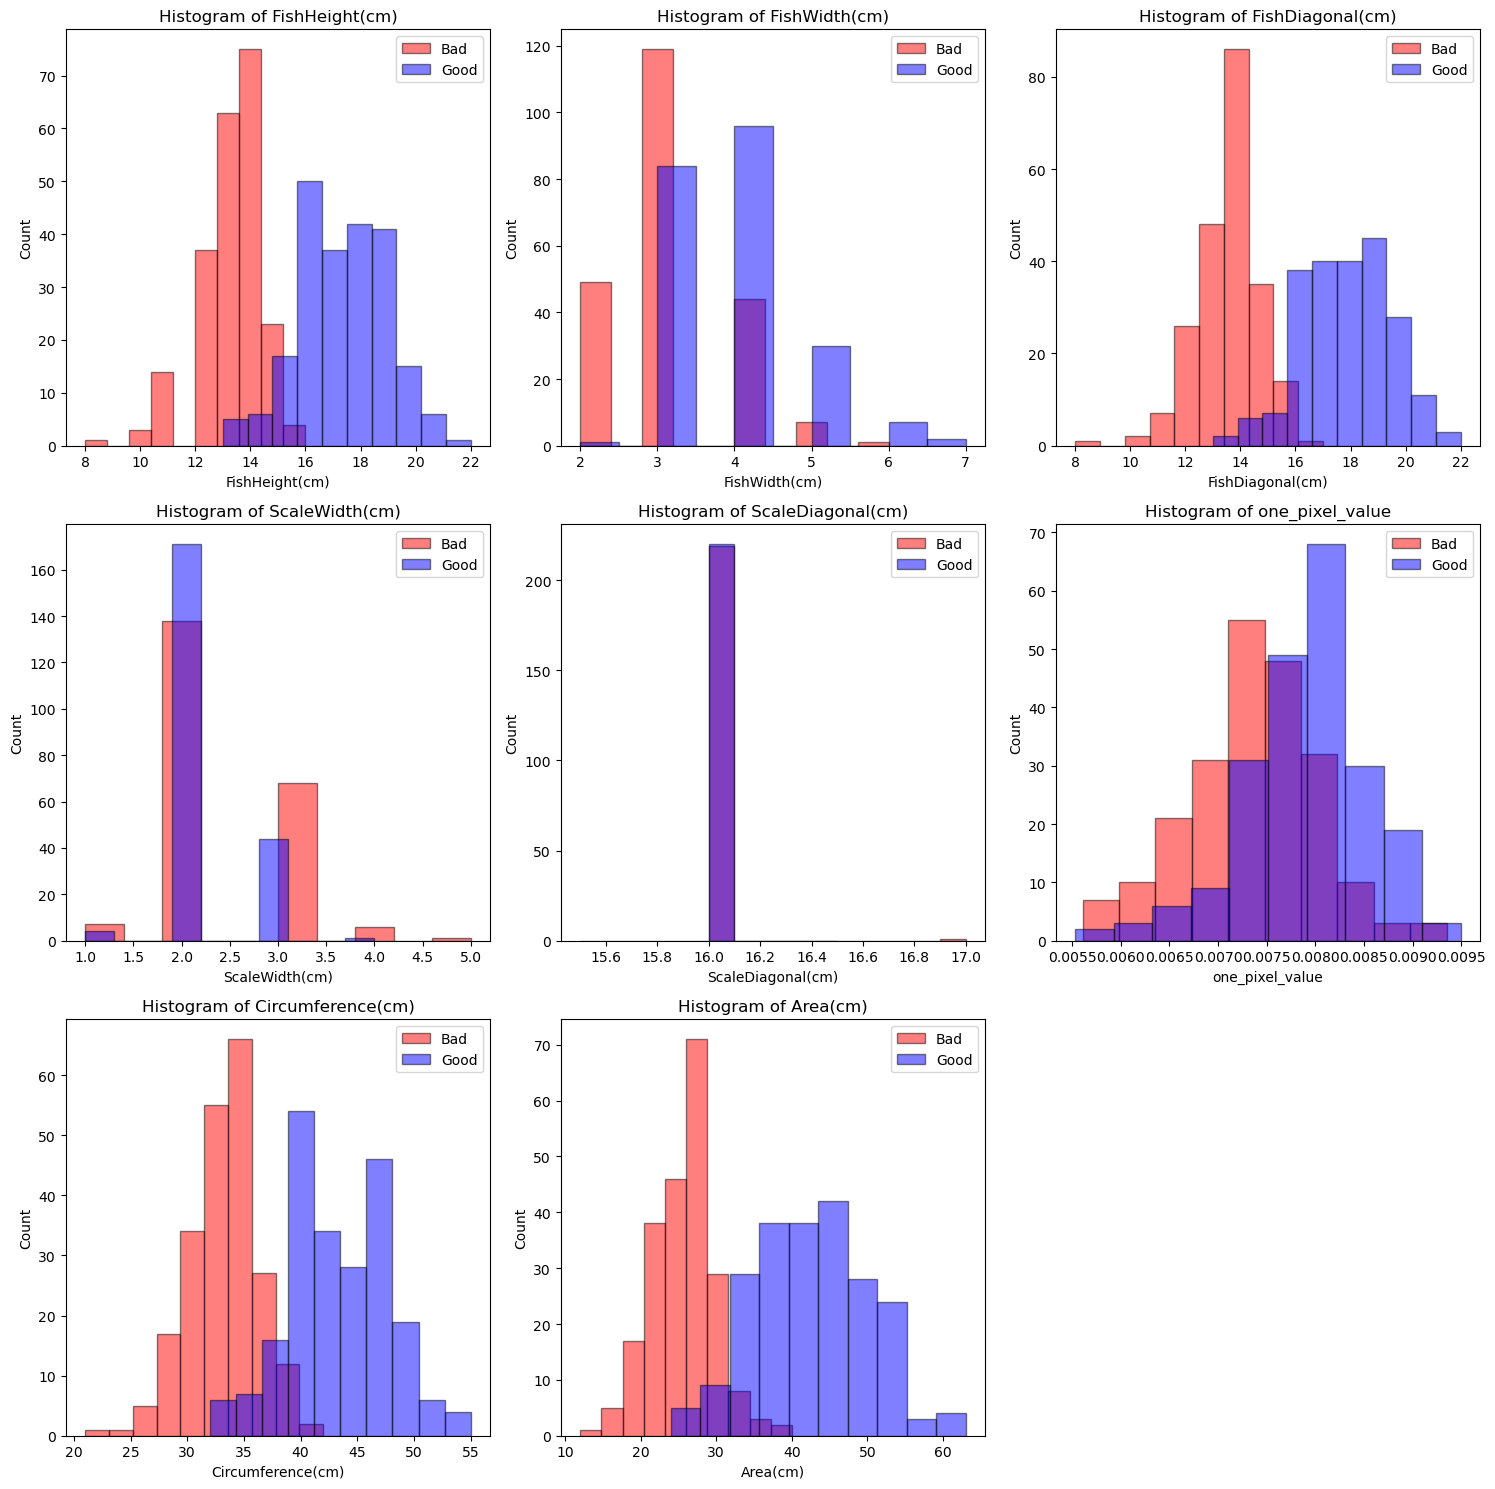

In [238]:
import math

def plot_allhist(colname_list):
    num_plots = len(colname_list)
    num_cols = min(num_plots, 3)  # Assuming a maximum of 3 columns for better visualization
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 15))

    for i, colname in enumerate(colname_list):
        row_index = i // num_cols
        col_index = i % num_cols
        ax = axes[row_index, col_index] if num_plots > 1 else axes
        ax.hist(Bad_df[colname], edgecolor='black', color='red', alpha=0.5, label='Bad')
        ax.hist(Good_df[colname], edgecolor='black', color='blue', alpha=0.5, label='Good')
        ax.set_xlabel(colname)
        ax.set_ylabel('Count')
        ax.set_title(f'Histogram of {colname}')
        ax.legend()

    if num_plots < num_rows * num_cols:
        # Hide empty subplots
        for i in range(num_plots, num_rows * num_cols):
            row_index = i // num_cols
            col_index = i % num_cols
            ax = axes[row_index, col_index] if num_plots > 1 else axes
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_allhist(['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)', 
           'ScaleWidth(cm)', 'ScaleDiagonal(cm)', 'one_pixel_value',
           'Circumference(cm)', 'Area(cm)'])

In [40]:
# V2 88% accuracy logistic regression features with 78% test accuracy on unbalanced data
X = final[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'Circumference(cm)', 'Area(cm)']]  # Features
y = final['Label']  # Target variable

In [41]:
print("Features (X):")
X.head()

Features (X):


,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),Circumference(cm),Area(cm)
77,12,3,13,31.0,21.0
351,12,2,12,31.0,24.0
436,12,3,13,31.0,22.0


In [42]:
print("\nTarget variable (y):")
y.tail()


Target variable (y):


77     0
351    0
436    0
Name: Label, dtype: int64

In [242]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pickle

In [243]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.1, 
                                                    random_state=42,
                                                    stratify=y)

# Model Training

v3 results

Training Decision Tree...
Accuracy for Decision Tree: 0.9090909090909091

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        22
           1       0.88      0.95      0.91        22

    accuracy                           0.91        44
   macro avg       0.91      0.91      0.91        44
weighted avg       0.91      0.91      0.91        44



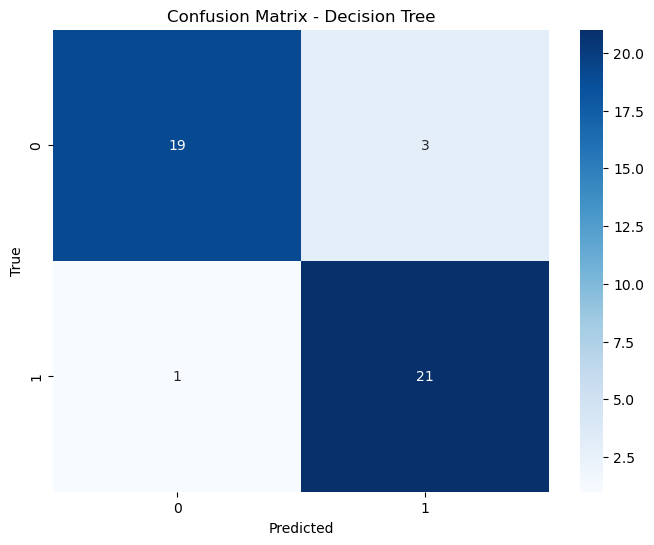

Training Random Forest...
Accuracy for Random Forest: 0.9090909090909091

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.91      0.91      0.91        22

    accuracy                           0.91        44
   macro avg       0.91      0.91      0.91        44
weighted avg       0.91      0.91      0.91        44



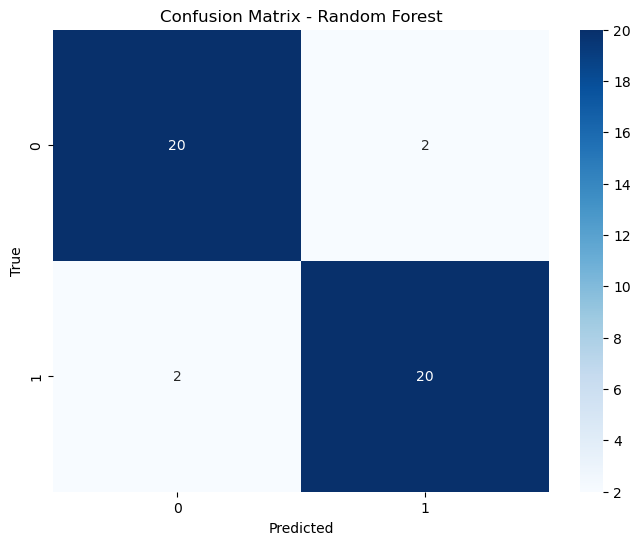

Training K-Nearest Neighbors...
Accuracy for K-Nearest Neighbors: 0.9090909090909091

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.91      0.91      0.91        22

    accuracy                           0.91        44
   macro avg       0.91      0.91      0.91        44
weighted avg       0.91      0.91      0.91        44



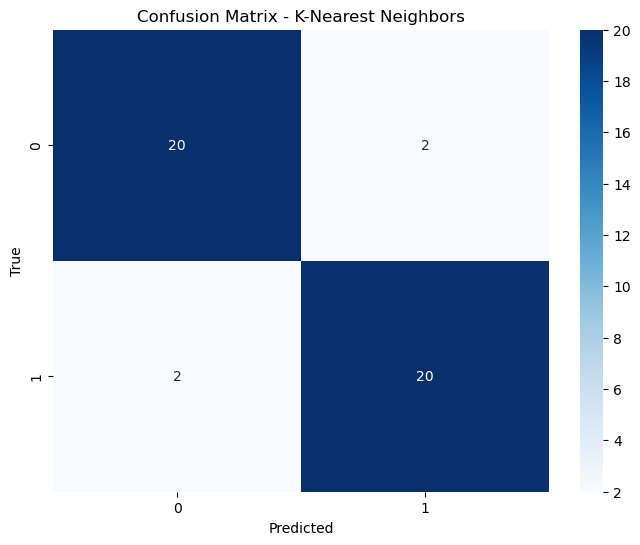

Training Naive Bayes...
Accuracy for Naive Bayes: 0.9318181818181818

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        22
           1       1.00      0.86      0.93        22

    accuracy                           0.93        44
   macro avg       0.94      0.93      0.93        44
weighted avg       0.94      0.93      0.93        44



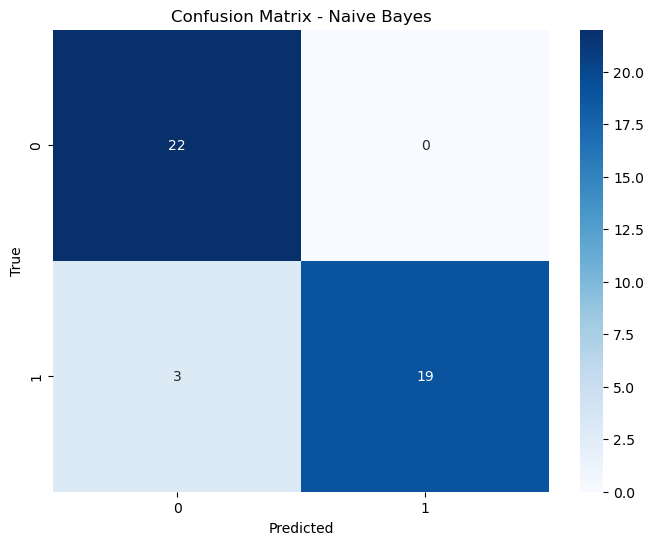

Training XGBClassifier...
Accuracy for XGBClassifier: 0.9318181818181818

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.91      0.95      0.93        22

    accuracy                           0.93        44
   macro avg       0.93      0.93      0.93        44
weighted avg       0.93      0.93      0.93        44



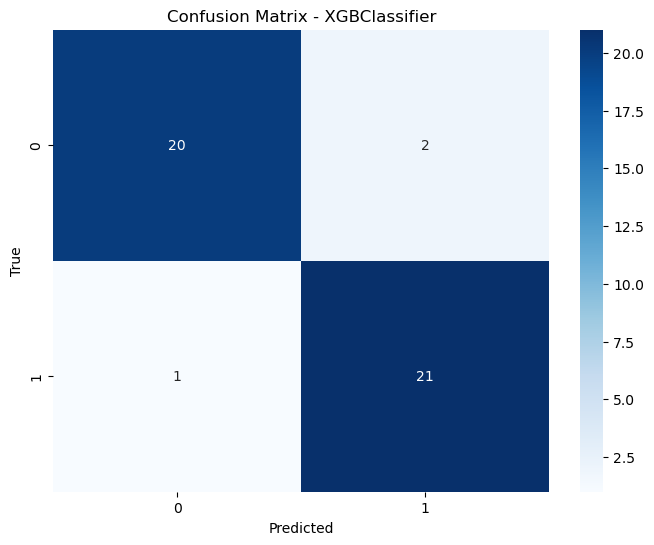

Training Logistic Regression...
Accuracy for Logistic Regression: 0.9318181818181818

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        22
           1       1.00      0.86      0.93        22

    accuracy                           0.93        44
   macro avg       0.94      0.93      0.93        44
weighted avg       0.94      0.93      0.93        44



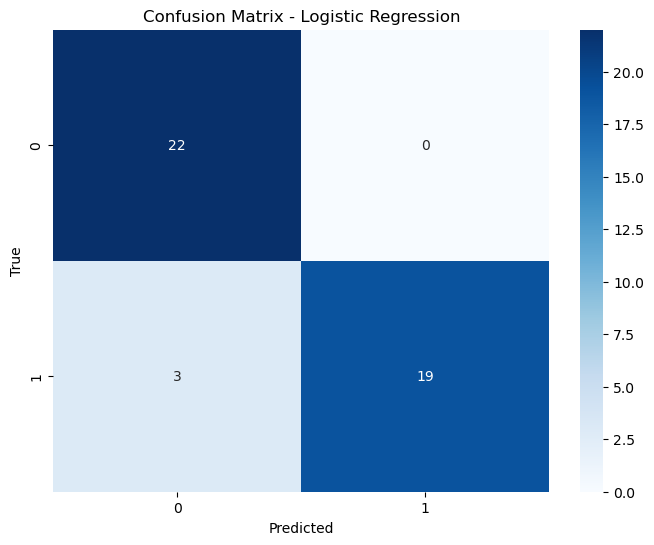

In [244]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Define classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBClassifier": XGBClassifier(),
    "Logistic Regression": LogisticRegression()
}


# Train and evaluate classifiers
for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {name}: {accuracy}\n")

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Generate classification report
    report = classification_report(y_test, y_pred)

    # Print the classification report
    print("Classification Report:")
    print(report)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    plt.close()

In [245]:
clf = XGBClassifier()
name = "XGBClassifier"
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for {name}: {accuracy}")

Accuracy for XGBClassifier: 0.9318181818181818


In [43]:
model_path = 'xgbv1.pkl'

In [247]:
model = clf
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

Load the ML model

In [44]:
with open(model_path, 'rb') as f:
    model = pickle.load(f)

v3 train data results

In [45]:
# X_test = X_train
# y_test = y_train
X_test = X
y_test = y

# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for model: {accuracy}\n")

# Generate classification report
report = classification_report(y_test, y_pred)

# Print the classification report
print("Classification Report:")
print(report)

Accuracy for model: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



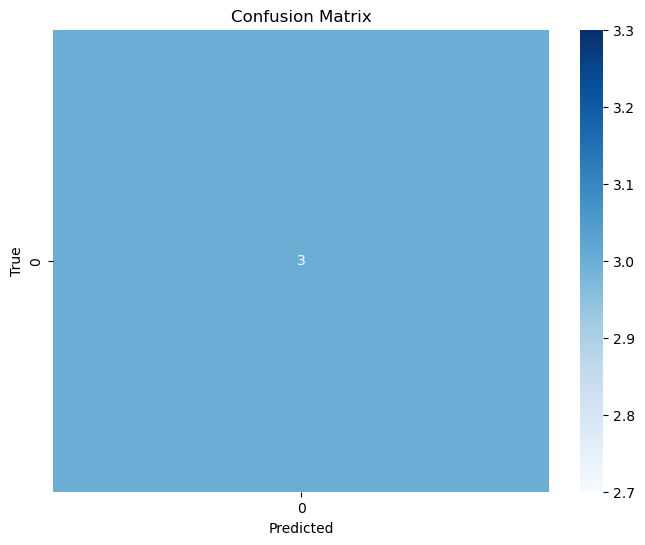

In [46]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix')
plt.show()
plt.close()

# Test data

In [267]:
filtered_df = feedback_df[feedback_df['Filename'].isin(m['Filename'])]

In [268]:
filtered_df['labels'].value_counts()

bad     238
good      1
Name: labels, dtype: int64

In [269]:
filtered_df

,id,type,labels,description,Filename,Date
7762,43177,sardine,bad,"Softness, Size",20240130093208534_sardine_bad.jpeg,2024-01-30
7763,43178,sardine,bad,"Softness, Size",20240130093304262_sardine_bad.jpeg,2024-01-30
7764,43179,sardine,bad,"Size, Softness",20240130093323026_sardine_bad.jpeg,2024-01-30
7765,43180,sardine,bad,"Size, Softness",20240130093336802_sardine_bad.jpeg,2024-01-30
7766,43181,sardine,bad,"Size, Softness",20240130093404006_sardine_bad.jpeg,2024-01-30
...,...,...,...,...,...,...
9023,49519,sardine,bad,Softness,20240228093318410_sardine_bad.jpeg,2024-02-28
9024,49520,sardine,bad,"Softness, Cuts and Damage",20240228093340727_sardine_bad.jpeg,2024-02-28
9025,49521,sardine,bad,Cuts and Damage,20240228093355952_sardine_bad.jpeg,2024-02-28
9026,49522,sardine,bad,Softness,20240228093407727_sardine_bad.jpeg,2024-02-28


In [270]:
filtered_df['description'].value_counts()

Softness                           137
Softness, Size                      26
Size, Softness                      22
Softness, Cuts and Damage           17
Size                                17
Cuts and Damage, Softness           10
Cuts and Damage                      3
Size, Cuts and Damage                3
Softness, Cuts and Damage, Size      1
Cuts and Damage, Size, Softness      1
Cuts and Damage, Softness, Size      1
Softness, Size, Cuts and Damage      1
Name: description, dtype: int64

In [271]:
filtered_df.shape

(239, 6)

In [272]:
filtered_df = (filtered_df[filtered_df['description'].str.contains('Size')])

In [273]:
filtered_df['labels'].value_counts()

bad    72
Name: labels, dtype: int64

In [274]:
filtered_df['description'].value_counts()

Softness, Size                     26
Size, Softness                     22
Size                               17
Size, Cuts and Damage               3
Softness, Cuts and Damage, Size     1
Cuts and Damage, Size, Softness     1
Cuts and Damage, Softness, Size     1
Softness, Size, Cuts and Damage     1
Name: description, dtype: int64

In [275]:
filtered_df.shape

(72, 6)

In [276]:
filtered_df

,id,type,labels,description,Filename,Date
7762,43177,sardine,bad,"Softness, Size",20240130093208534_sardine_bad.jpeg,2024-01-30
7763,43178,sardine,bad,"Softness, Size",20240130093304262_sardine_bad.jpeg,2024-01-30
7764,43179,sardine,bad,"Size, Softness",20240130093323026_sardine_bad.jpeg,2024-01-30
7765,43180,sardine,bad,"Size, Softness",20240130093336802_sardine_bad.jpeg,2024-01-30
7766,43181,sardine,bad,"Size, Softness",20240130093404006_sardine_bad.jpeg,2024-01-30
...,...,...,...,...,...,...
8794,48993,sardine,bad,Size,20240222102214684_sardine_bad.jpeg,2024-02-22
9011,49506,sardine,bad,"Softness, Size",20240228093016656_sardine_bad.jpeg,2024-02-28
9012,49507,sardine,bad,"Softness, Size",20240228093032129_sardine_bad.jpeg,2024-02-28
9014,49509,sardine,bad,"Softness, Size",20240228093056751_sardine_bad.jpeg,2024-02-28


In [277]:
new_df = m[m['Filename'].isin(filtered_df['Filename'])]

In [278]:
new_df

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
0,20240130093208534_sardine_bad.jpeg,12,3,12,16,3,0.006817,True,True,31,21,0
1,20240130093304262_sardine_bad.jpeg,14,2,14,16,2,0.007674,True,True,33,24,0
2,20240130093323026_sardine_bad.jpeg,12,2,12,16,2,0.006811,True,True,30,18,0
3,20240130093336802_sardine_bad.jpeg,13,3,13,16,3,0.007561,True,True,31,21,0
4,20240130093404006_sardine_bad.jpeg,14,4,15,16,3,0.006885,True,True,35,27,0
...,...,...,...,...,...,...,...,...,...,...,...,...
218,20240222102214684_sardine_bad.jpeg,12,2,12,16,1,0.006617,True,True,29,20,0
226,20240228093016656_sardine_bad.jpeg,13,5,14,16,3,0.006462,True,True,33,24,0
227,20240228093032129_sardine_bad.jpeg,13,2,13,16,4,0.006382,True,True,33,24,0
229,20240228093056751_sardine_bad.jpeg,13,3,14,16,3,0.006987,True,True,32,22,0


In [279]:
new_df2 = m[m['Label']==1]
new_df2

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
244,20240208110604119_sardine_good.jpeg,19,3,20,16,2,0.008974,True,True,47,49,1
245,20240208110613710_sardine_good.jpeg,15,3,16,16,2,0.007917,True,True,38,30,1
246,20240208110622902_sardine_good.jpeg,21,4,21,16,3,0.009259,True,True,51,57,1
247,20240208110630401_sardine_good.jpeg,20,4,20,16,4,0.008889,True,True,47,57,1
248,20240208110639602_sardine_good.jpeg,17,4,18,16,2,0.007952,True,True,43,43,1
...,...,...,...,...,...,...,...,...,...,...,...,...
328,20240215105859882_sardine_good.jpeg,15,3,16,16,2,0.007866,True,True,39,39,1
329,20240215105907544_sardine_good.jpeg,17,4,18,16,2,0.008515,True,True,43,40,1
330,20240215105915691_sardine_good.jpeg,16,3,16,16,3,0.008412,True,True,40,37,1
331,20240215105923321_sardine_good.jpeg,20,4,20,16,1,0.008686,True,True,48,57,1


In [280]:
new_df.shape, new_df2.shape

((72, 12), (89, 12))

In [281]:
new_df2 = new_df2.iloc[:72]
new_df2.shape

(72, 12)

In [282]:
final = pd.concat([new_df, new_df2])

In [283]:
final.shape

(144, 12)

In [284]:
Bad_df = final[final['Label']==0]
Good_df = final[final['Label']==1].iloc[:72]

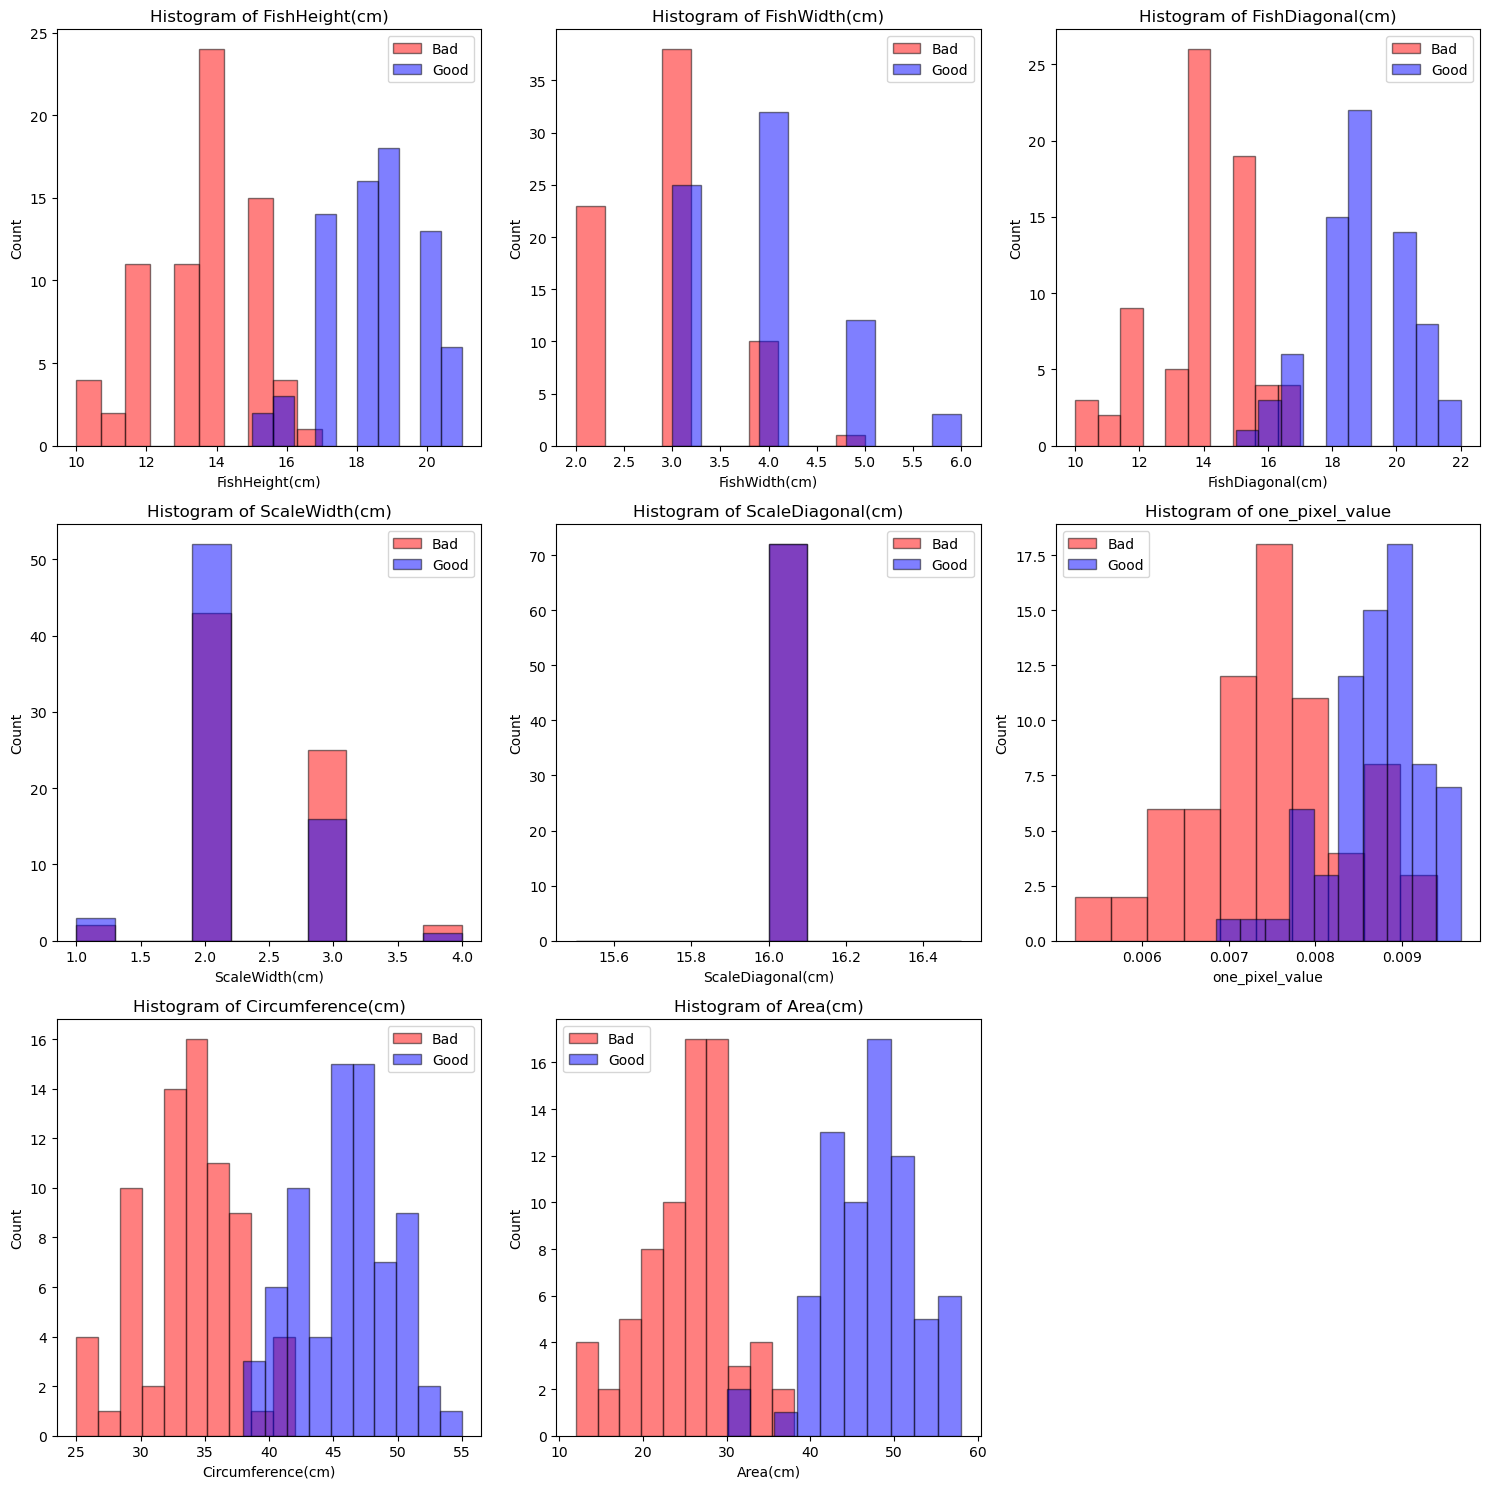

In [285]:
import math

def plot_allhist(colname_list):
    num_plots = len(colname_list)
    num_cols = min(num_plots, 3)  # Assuming a maximum of 3 columns for better visualization
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 15))

    for i, colname in enumerate(colname_list):
        row_index = i // num_cols
        col_index = i % num_cols
        ax = axes[row_index, col_index] if num_plots > 1 else axes
        ax.hist(Bad_df[colname], edgecolor='black', color='red', alpha=0.5, label='Bad')
        ax.hist(Good_df[colname], edgecolor='black', color='blue', alpha=0.5, label='Good')
        ax.set_xlabel(colname)
        ax.set_ylabel('Count')
        ax.set_title(f'Histogram of {colname}')
        ax.legend()

    if num_plots < num_rows * num_cols:
        # Hide empty subplots
        for i in range(num_plots, num_rows * num_cols):
            row_index = i // num_cols
            col_index = i % num_cols
            ax = axes[row_index, col_index] if num_plots > 1 else axes
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_allhist(['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)', 
           'ScaleWidth(cm)', 'ScaleDiagonal(cm)', 'one_pixel_value',
           'Circumference(cm)', 'Area(cm)'])

In [286]:
# V3 93% accuracy xgb features with 94% test accuracy on unbalanced data
X = final[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'Circumference(cm)', 'Area(cm)']]  # Features
y = final['Label']  # Target variable

In [287]:
print("Features (X):")
X.head()

Features (X):


,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),Circumference(cm),Area(cm)
0,12,3,12,31,21
1,14,2,14,33,24
2,12,2,12,30,18
3,13,3,13,31,21
4,14,4,15,35,27


In [288]:
print("\nTarget variable (y):")
y.tail()


Target variable (y):


311    1
312    1
313    1
314    1
315    1
Name: Label, dtype: int64

In [289]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pickle

In [290]:
model_path = 'xgbv1.pkl'

Load the ML model

In [291]:
with open(model_path, 'rb') as f:
    model = pickle.load(f)

v3 test data results

In [292]:
X_test = X
y_test = y

# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for model: {accuracy}\n")

# Generate classification report
report = classification_report(y_test, y_pred)

# Print the classification report
print("Classification Report:")
print(report)

Accuracy for model: 0.9375

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        72
           1       0.91      0.97      0.94        72

    accuracy                           0.94       144
   macro avg       0.94      0.94      0.94       144
weighted avg       0.94      0.94      0.94       144



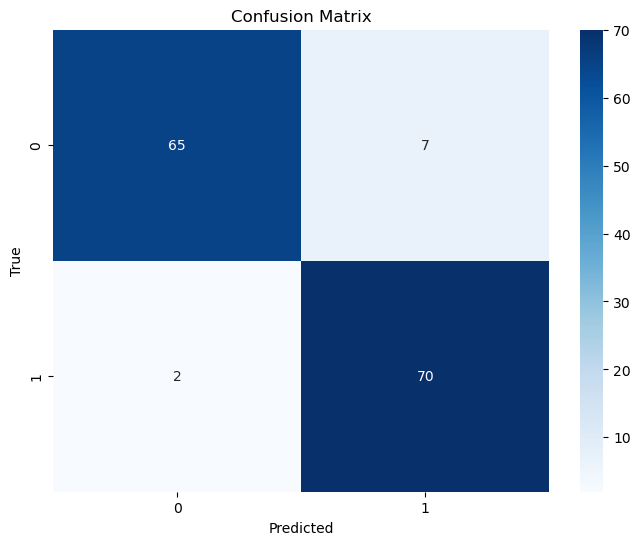

In [293]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix')
plt.show()
plt.close()

In [2]:
feedback_df = pd.read_csv(r"C:\Users\sowmy\Downloads\QzenseLabs\testing_dataset2.csv")
feedback_df['Filename'] = feedback_df['image_url'].apply(lambda x: os.path.basename(x))
feedback_df['Date'] = feedback_df['Filename'].apply(lambda x: os.path.splitext(x)[0].split('_')[0])
feedback_df['Date'] = feedback_df['Date'].apply(lambda x: f'{x[0:4]}-{x[4:6]}-{x[6:8]}')
feedback_df.drop(['image_url', 'Unnamed: 0'], axis=1, inplace=True)

In [3]:
feedback_df

,id,type,labels,description,Filename,Date
0,51761,white prawns,bad,Softness,20240306105949897_white prawns_bad.jpeg,2024-03-06
1,24398,white prawns,bad,Red Head in Prawns,20230923093438588_white prawns_bad.jpeg,2023-09-23
2,51762,white prawns,bad,Softness,20240306105957000_white prawns_bad.jpeg,2024-03-06
3,24410,white prawns,bad,Red Head in Prawns,20230923094928373_white prawns_bad.jpeg,2023-09-23
4,24411,white prawns,bad,Red Head in Prawns,20230923094938856_white prawns_bad.jpeg,2023-09-23
...,...,...,...,...,...,...
15783,59937,white prawns,bad,Softness,20240406104556694_white prawns_bad.jpeg,2024-04-06
15784,59938,white prawns,bad,"Cuts and Damage, Softness",20240406104606115_white prawns_bad.jpeg,2024-04-06
15785,59939,white prawns,bad,Softness,20240406104618304_white prawns_bad.jpeg,2024-04-06
15786,59940,white prawns,bad,Softness,20240406104631758_white prawns_bad.jpeg,2024-04-06


In [4]:
feedback_df['labels'].value_counts()

bad     15768
good       20
Name: labels, dtype: int64